In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Manual Dataset Loading

file_path = "../data/heart.csv"

with open(file_path, "r") as file:
    raw_lines = file.readlines()

# Remove newline characters
raw_lines = [line.strip() for line in raw_lines]

# Detect delimiter manually (assuming comma-separated)
delimiter = ","

# Split header and data
header = raw_lines[0].split(delimiter)
rows = [line.split(delimiter) for line in raw_lines[1:]]

print("Header columns:", header)
print("Total rows loaded:", len(rows))

Header columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
Total rows loaded: 303


In [3]:
# Create DataFrame from Parsed Data

import pandas as pd

df = pd.DataFrame(rows, columns=header)

# Convert numeric columns safely
for col in df.columns:
    try:
        df[col] = df[col].astype(float)
    except:
        pass

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,3.0,145.0,233.0,1.0,0.0,150.0,0.0,2.3,0.0,0.0,1.0,1.0
1,37.0,1.0,2.0,130.0,250.0,0.0,1.0,187.0,0.0,3.5,0.0,0.0,2.0,1.0
2,41.0,0.0,1.0,130.0,204.0,0.0,0.0,172.0,0.0,1.4,2.0,0.0,2.0,1.0
3,56.0,1.0,1.0,120.0,236.0,0.0,1.0,178.0,0.0,0.8,2.0,0.0,2.0,1.0
4,57.0,0.0,0.0,120.0,354.0,0.0,1.0,163.0,1.0,0.6,2.0,0.0,2.0,1.0


In [4]:
# Manual Pagination

def paginate_dataframe(dataframe, page_size, page_number):
    start = page_size * (page_number - 1)
    end = start + page_size
    return dataframe.iloc[start:end]

# Example usage
page_size = 10
page_number = 1

paginated_df = paginate_dataframe(df, page_size, page_number)
paginated_df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,3.0,145.0,233.0,1.0,0.0,150.0,0.0,2.3,0.0,0.0,1.0,1.0
1,37.0,1.0,2.0,130.0,250.0,0.0,1.0,187.0,0.0,3.5,0.0,0.0,2.0,1.0
2,41.0,0.0,1.0,130.0,204.0,0.0,0.0,172.0,0.0,1.4,2.0,0.0,2.0,1.0
3,56.0,1.0,1.0,120.0,236.0,0.0,1.0,178.0,0.0,0.8,2.0,0.0,2.0,1.0
4,57.0,0.0,0.0,120.0,354.0,0.0,1.0,163.0,1.0,0.6,2.0,0.0,2.0,1.0
5,57.0,1.0,0.0,140.0,192.0,0.0,1.0,148.0,0.0,0.4,1.0,0.0,1.0,1.0
6,56.0,0.0,1.0,140.0,294.0,0.0,0.0,153.0,0.0,1.3,1.0,0.0,2.0,1.0
7,44.0,1.0,1.0,120.0,263.0,0.0,1.0,173.0,0.0,0.0,2.0,0.0,3.0,1.0
8,52.0,1.0,2.0,172.0,199.0,1.0,1.0,162.0,0.0,0.5,2.0,0.0,3.0,1.0
9,57.0,1.0,2.0,150.0,168.0,0.0,1.0,174.0,0.0,1.6,2.0,0.0,2.0,1.0


In [5]:
# Manual Sorting

def sort_dataframe(dataframe, column_name, ascending=True):
    sorted_rows = sorted(
        dataframe.values.tolist(),
        key=lambda x: x[dataframe.columns.get_loc(column_name)],
        reverse=not ascending
    )
    return pd.DataFrame(sorted_rows, columns=dataframe.columns)

# Example usage
sorted_df = sort_dataframe(df, "age", ascending=True)
sorted_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,29.0,1.0,1.0,130.0,204.0,0.0,0.0,202.0,0.0,0.0,2.0,0.0,2.0,1.0
1,34.0,1.0,3.0,118.0,182.0,0.0,0.0,174.0,0.0,0.0,2.0,0.0,2.0,1.0
2,34.0,0.0,1.0,118.0,210.0,0.0,1.0,192.0,0.0,0.7,2.0,0.0,2.0,1.0
3,35.0,0.0,0.0,138.0,183.0,0.0,1.0,182.0,0.0,1.4,2.0,0.0,2.0,1.0
4,35.0,1.0,1.0,122.0,192.0,0.0,1.0,174.0,0.0,0.0,2.0,0.0,2.0,1.0


In [6]:
# Identify Numerical Columns

numerical_columns = []

for col in df.columns:
    is_numeric = True
    for value in df[col]:
        if not isinstance(value, (int, float)):
            is_numeric = False
            break
    if is_numeric:
        numerical_columns.append(col)

print("Numerical columns:", numerical_columns)

Numerical columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [7]:
# Manual Mean

def manual_mean(values):
    total = 0
    count = 0
    for v in values:
        total += v
        count += 1
    return total / count if count != 0 else None

In [8]:
# Manual Median

def manual_median(values):
    sorted_values = sorted(values)
    n = len(sorted_values)
    mid = n // 2

    if n % 2 == 0:
        return (sorted_values[mid - 1] + sorted_values[mid]) / 2
    else:
        return sorted_values[mid]

In [9]:
# Manual Mode

def manual_mode(values):
    frequency = {}
    for v in values:
        if v in frequency:
            frequency[v] += 1
        else:
            frequency[v] = 1

    max_count = 0
    mode_value = None

    for key, count in frequency.items():
        if count > max_count:
            max_count = count
            mode_value = key

    return mode_value

In [10]:
# Manual Min and Max

def manual_min(values):
    minimum = values[0]
    for v in values:
        if v < minimum:
            minimum = v
    return minimum

def manual_max(values):
    maximum = values[0]
    for v in values:
        if v > maximum:
            maximum = v
    return maximum

In [11]:
# Manual Standard Deviation

import math

def manual_std(values):
    mean_value = manual_mean(values)
    squared_diff_sum = 0

    for v in values:
        squared_diff_sum += (v - mean_value) ** 2

    variance = squared_diff_sum / len(values)
    return math.sqrt(variance)

In [12]:
# Manual Summary Statistics Table

summary_stats = {}

for col in numerical_columns:
    values = df[col].tolist()

    summary_stats[col] = {
        "mean": manual_mean(values),
        "median": manual_median(values),
        "mode": manual_mode(values),
        "min": manual_min(values),
        "max": manual_max(values),
        "std": manual_std(values)
    }

summary_df = pd.DataFrame(summary_stats).T
summary_df

,mean,median,mode,min,max,std
age,54.366337,55.0,58.0,29.0,77.0,9.067102
sex,0.683168,1.0,1.0,0.0,1.0,0.465241
cp,0.966997,1.0,0.0,0.0,3.0,1.030348
trestbps,131.623762,130.0,120.0,94.0,200.0,17.509178
chol,246.264026,240.0,204.0,126.0,564.0,51.745151
fbs,0.148515,0.0,0.0,0.0,1.0,0.355610
restecg,0.528053,1.0,1.0,0.0,2.0,0.524991
thalach,149.646865,153.0,162.0,71.0,202.0,22.867333
exang,0.326733,0.0,0.0,0.0,1.0,0.469019
oldpeak,1.039604,0.8,0.0,0.0,6.2,1.159157


In [13]:
# Define Missing Value Rules

def is_missing(value):
    if value == "":
        return True
    if isinstance(value, str) and value.strip().lower() in ["nan", "null", "none", "?"]:
        return True
    return False

In [14]:
# Detect Missing Values Manually

missing_report = {}

for col in df.columns:
    missing_count = 0
    for value in df[col]:
        if is_missing(value):
            missing_count += 1
    missing_report[col] = missing_count

missing_report

{'age': 0,
 'sex': 0,
 'cp': 0,
 'trestbps': 0,
 'chol': 0,
 'fbs': 0,
 'restecg': 0,
 'thalach': 0,
 'exang': 0,
 'oldpeak': 0,
 'slope': 0,
 'ca': 0,
 'thal': 0,
 'target': 0}

In [15]:
# Extract Rows with Missing Values

rows_with_missing = []

for index, row in df.iterrows():
    for value in row:
        if is_missing(value):
            rows_with_missing.append(index)
            break

unique_missing_rows = list(set(rows_with_missing))
len(unique_missing_rows)

0

In [16]:
# Mean Imputation (Manual)

def mean_imputation(column_values):
    clean_values = [v for v in column_values if not is_missing(v)]
    mean_value = manual_mean(clean_values)

    imputed_values = []
    for v in column_values:
        if is_missing(v):
            imputed_values.append(mean_value)
        else:
            imputed_values.append(v)

    return imputed_values

In [17]:
# Median Imputation (Manual)

def median_imputation(column_values):
    clean_values = [v for v in column_values if not is_missing(v)]
    median_value = manual_median(clean_values)

    imputed_values = []
    for v in column_values:
        if is_missing(v):
            imputed_values.append(median_value)
        else:
            imputed_values.append(v)

    return imputed_values

In [18]:
# Forward Fill Imputation (Manual)

def forward_fill(column_values):
    filled_values = []
    last_valid = None

    for v in column_values:
        if is_missing(v):
            filled_values.append(last_valid)
        else:
            filled_values.append(v)
            last_valid = v

    return filled_values

In [19]:
# Apply Median Imputation to Numerical Columns

for col in numerical_columns:
    df[col] = median_imputation(df[col].tolist())

In [20]:
# Verify Missing Values After Imputation

post_imputation_report = {}

for col in df.columns:
    count = 0
    for value in df[col]:
        if is_missing(value):
            count += 1
    post_imputation_report[col] = count

post_imputation_report

{'age': 0,
 'sex': 0,
 'cp': 0,
 'trestbps': 0,
 'chol': 0,
 'fbs': 0,
 'restecg': 0,
 'thalach': 0,
 'exang': 0,
 'oldpeak': 0,
 'slope': 0,
 'ca': 0,
 'thal': 0,
 'target': 0}

In [21]:
# Verify Missing Values After Imputation

post_imputation_report = {}

for col in df.columns:
    count = 0
    for value in df[col]:
        if is_missing(value):
            count += 1
    post_imputation_report[col] = count

post_imputation_report

{'age': 0,
 'sex': 0,
 'cp': 0,
 'trestbps': 0,
 'chol': 0,
 'fbs': 0,
 'restecg': 0,
 'thalach': 0,
 'exang': 0,
 'oldpeak': 0,
 'slope': 0,
 'ca': 0,
 'thal': 0,
 'target': 0}

In [22]:
# Manual Duplicate Detection

def find_duplicate_indices(dataframe):
    seen_rows = []
    duplicate_indices = []

    for idx, row in dataframe.iterrows():
        row_tuple = tuple(row.values.tolist())
        if row_tuple in seen_rows:
            duplicate_indices.append(idx)
        else:
            seen_rows.append(row_tuple)

    return duplicate_indices

duplicate_indices = find_duplicate_indices(df)

print("Number of duplicate rows found:", len(duplicate_indices))
duplicate_indices[:10]

Number of duplicate rows found: 1


[164]

In [23]:
# Inspect Duplicate Rows

if len(duplicate_indices) > 0:
    df.loc[duplicate_indices].head()
else:
    print("No duplicate rows detected.")

In [24]:
# Manual Duplicate Removal

def remove_duplicates(dataframe, duplicate_indices):
    cleaned_rows = []

    for idx, row in dataframe.iterrows():
        if idx not in duplicate_indices:
            cleaned_rows.append(row.values.tolist())

    return pd.DataFrame(cleaned_rows, columns=dataframe.columns)

df_before = df.copy()
df = remove_duplicates(df, duplicate_indices)

print("Shape before duplicate removal:", df_before.shape)
print("Shape after duplicate removal:", df.shape)

Shape before duplicate removal: (303, 14)
Shape after duplicate removal: (302, 14)


In [25]:
# Verify Duplicate Removal

remaining_duplicates = find_duplicate_indices(df)
print("Duplicates after cleaning:", len(remaining_duplicates))

Duplicates after cleaning: 0


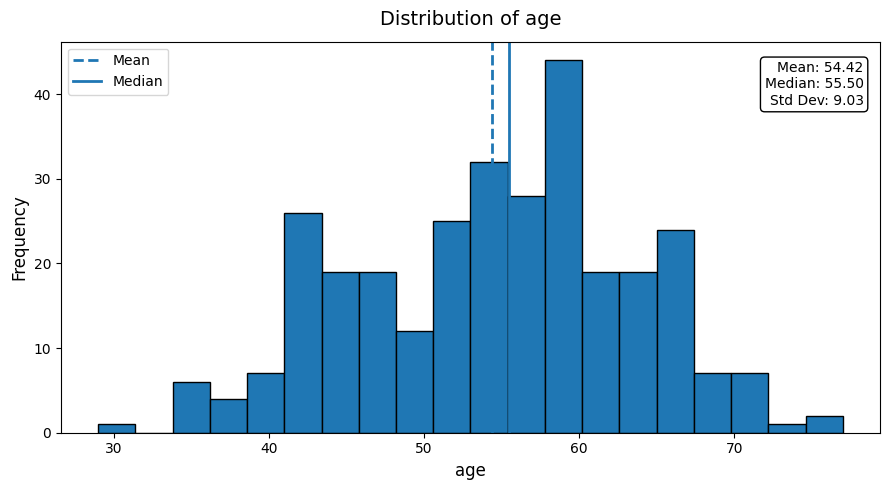

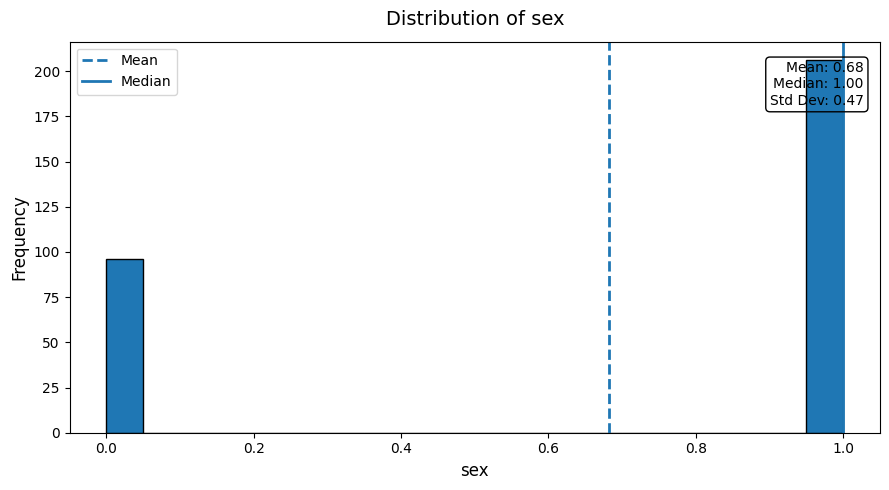

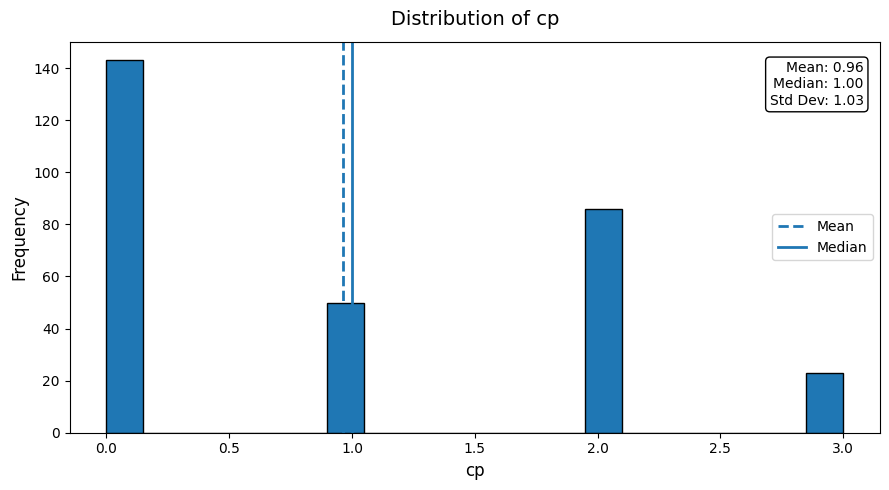

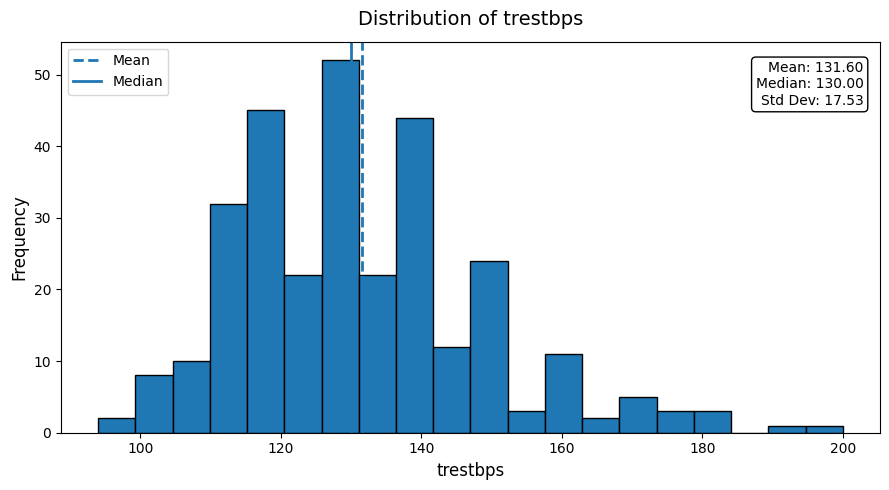

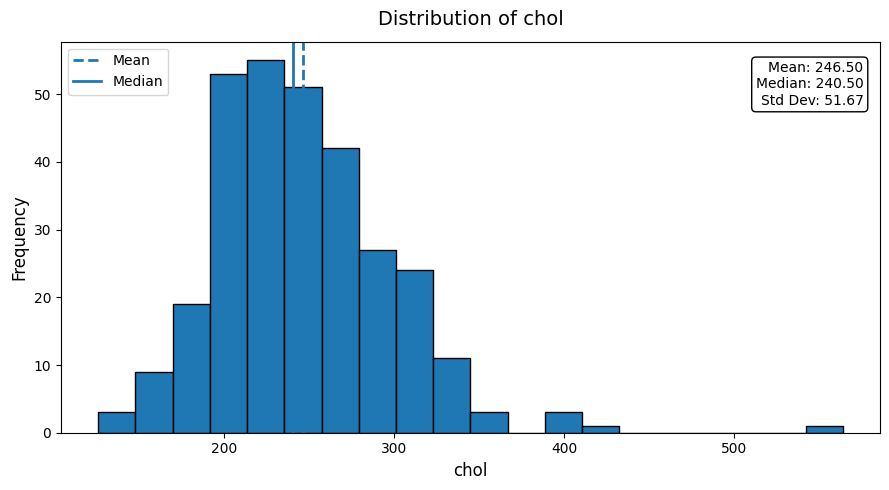

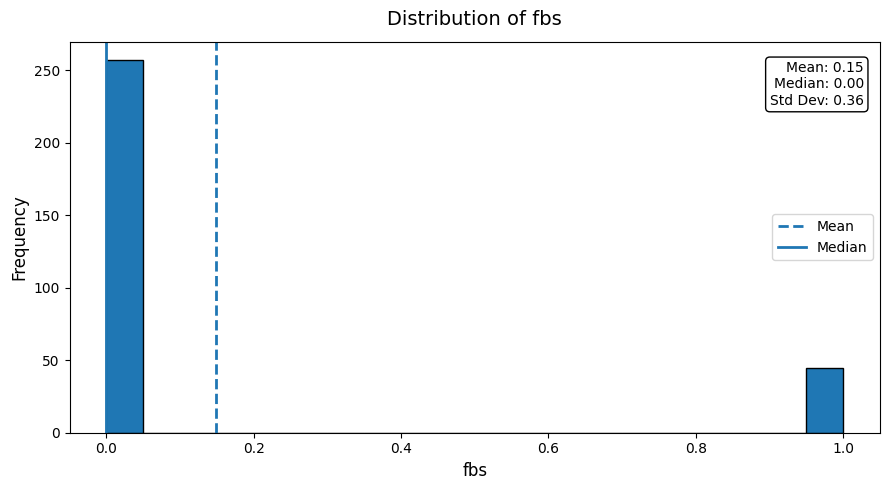

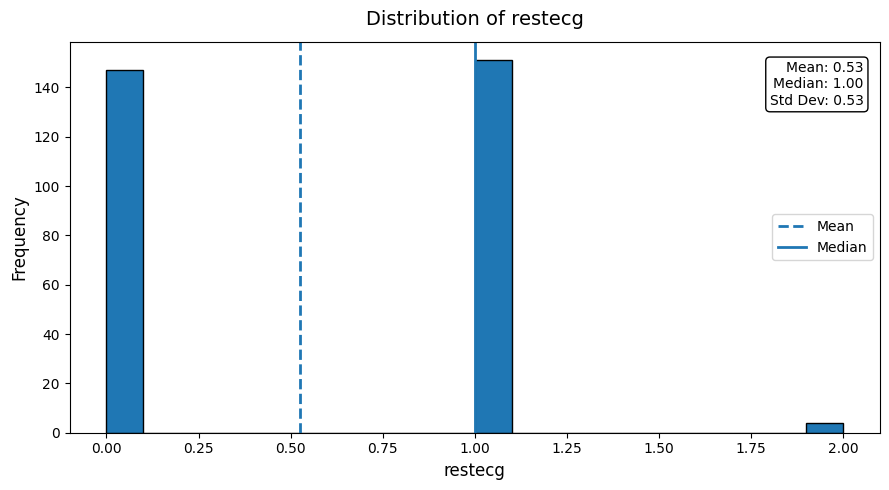

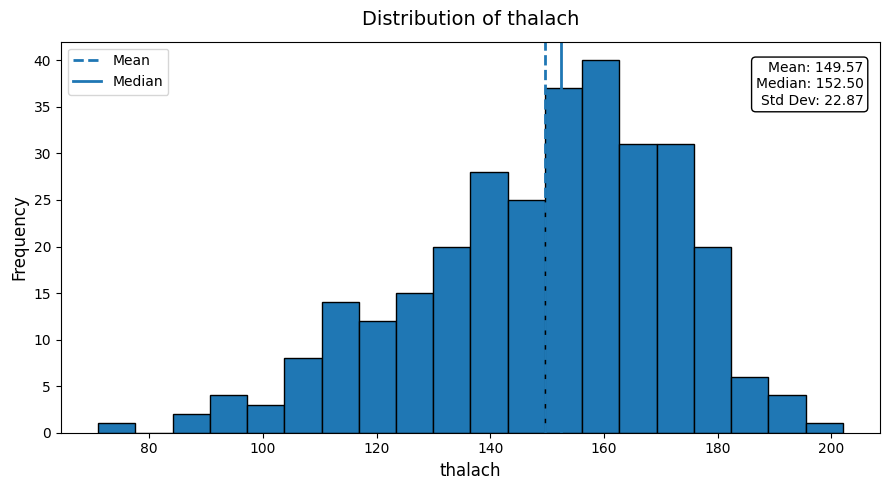

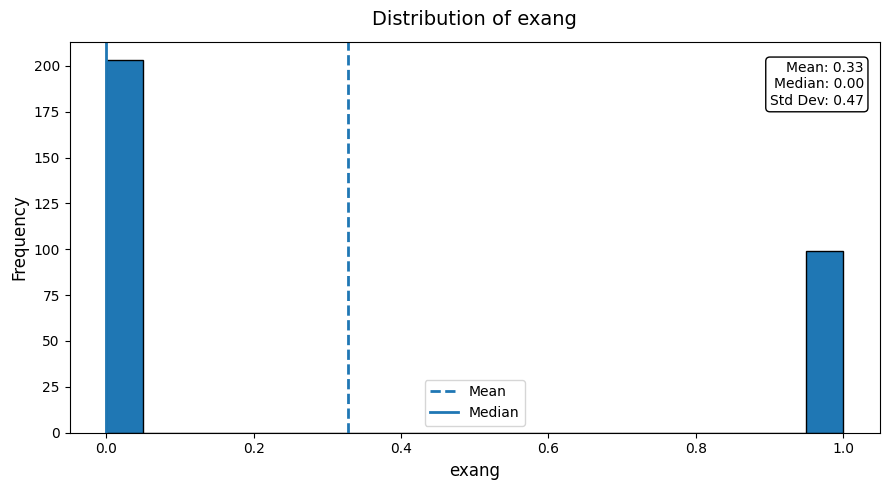

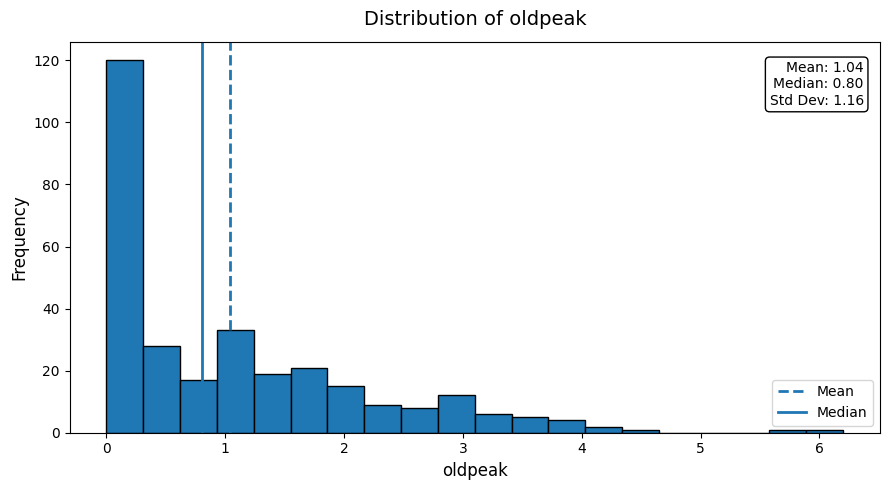

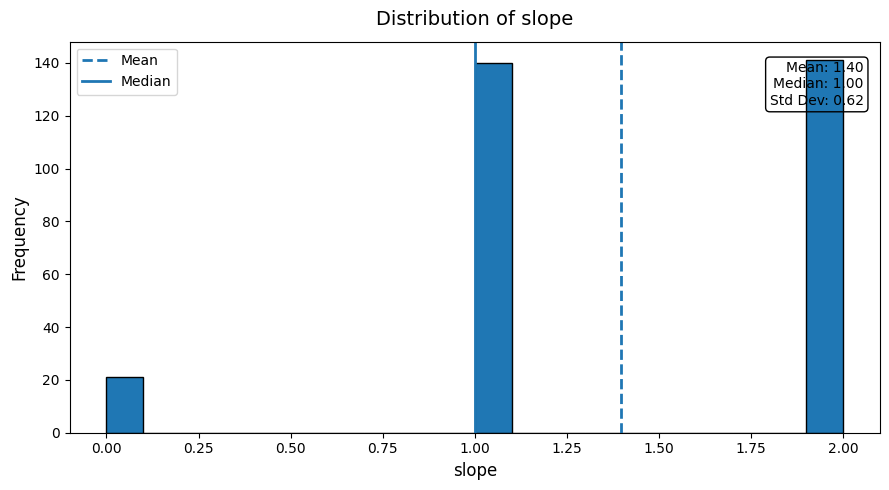

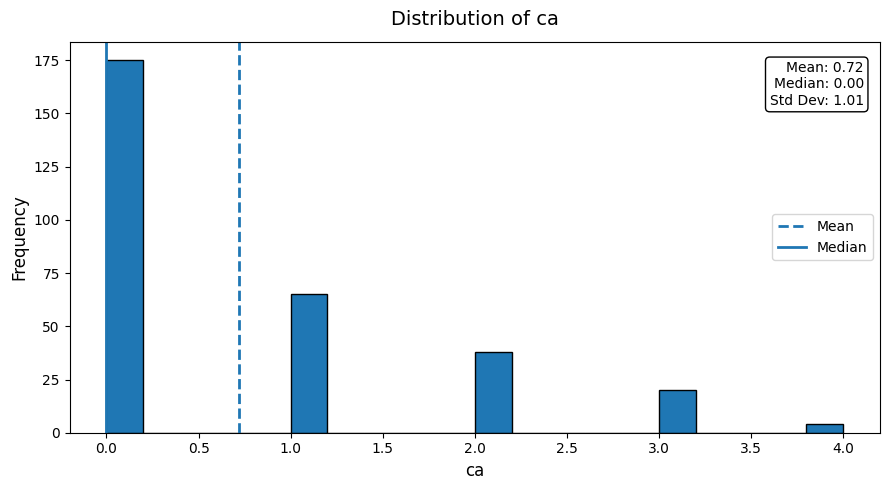

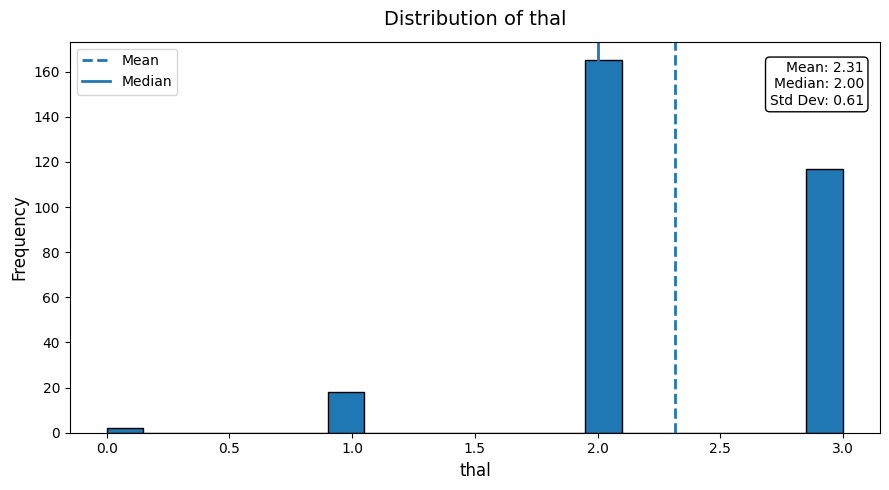

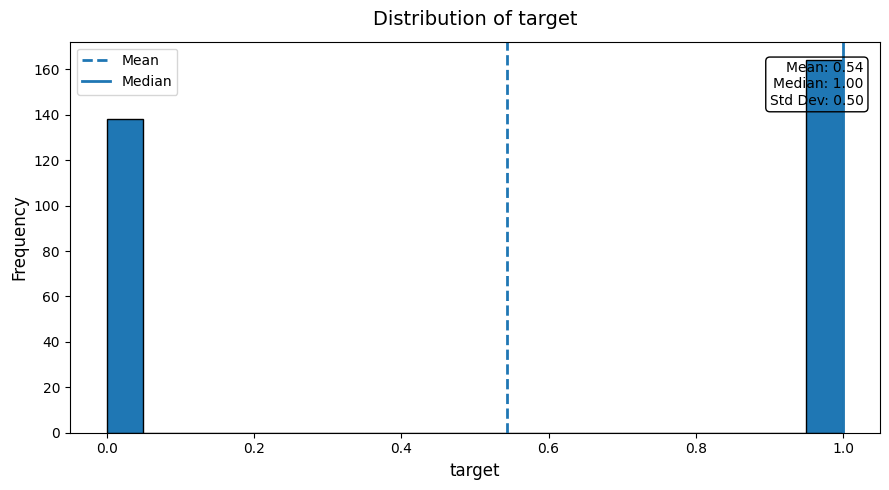

In [26]:
# Clean Histogram Template

for col in numerical_columns:
    values = df[col].tolist()
    
    mean_val = manual_mean(values)
    median_val = manual_median(values)
    std_val = manual_std(values)

    plt.figure(figsize=(9, 5))
    
    plt.hist(
        values,
        bins=20,
        edgecolor='black'
    )
    
    # Statistical reference lines
    plt.axvline(mean_val, linestyle='--', linewidth=2, label="Mean")
    plt.axvline(median_val, linestyle='-', linewidth=2, label="Median")
    
    plt.title(f"Distribution of {col}", fontsize=14, pad=12)
    plt.xlabel(col, fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    
    plt.legend()
    
    # Clean annotation box
    text = (
        f"Mean: {mean_val:.2f}\n"
        f"Median: {median_val:.2f}\n"
        f"Std Dev: {std_val:.2f}"
    )
    
    plt.text(
        0.98, 0.95,
        text,
        transform=plt.gca().transAxes,
        fontsize=10,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle="round", fill=False)
    )
    
    plt.tight_layout()
    plt.show()

C:\Users\reyan\AppData\Local\Temp\ipykernel_12664\331188462.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


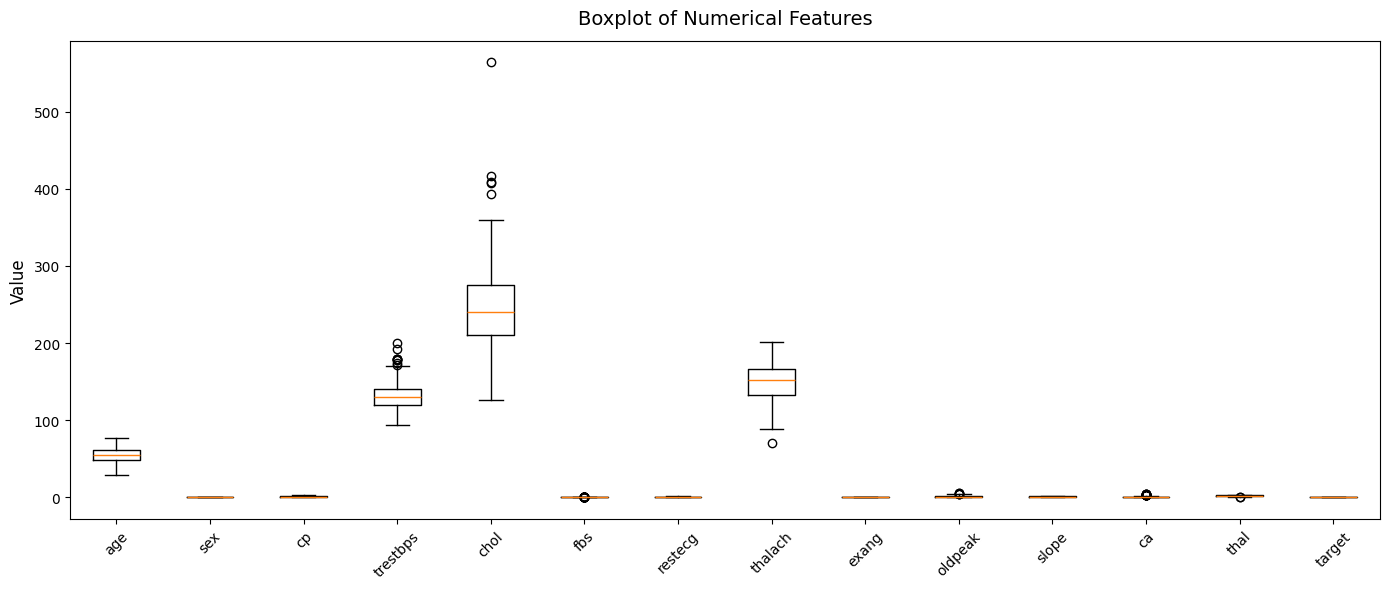

In [27]:
# Clean Boxplot for All Numerical Columns

plt.figure(figsize=(14, 6))

plt.boxplot(
    [df[col].tolist() for col in numerical_columns],
    labels=numerical_columns,
    patch_artist=False
)

plt.title("Boxplot of Numerical Features", fontsize=14, pad=12)
plt.ylabel("Value", fontsize=12)
plt.xticks(rotation=45, fontsize=10)

plt.tight_layout()
plt.show()

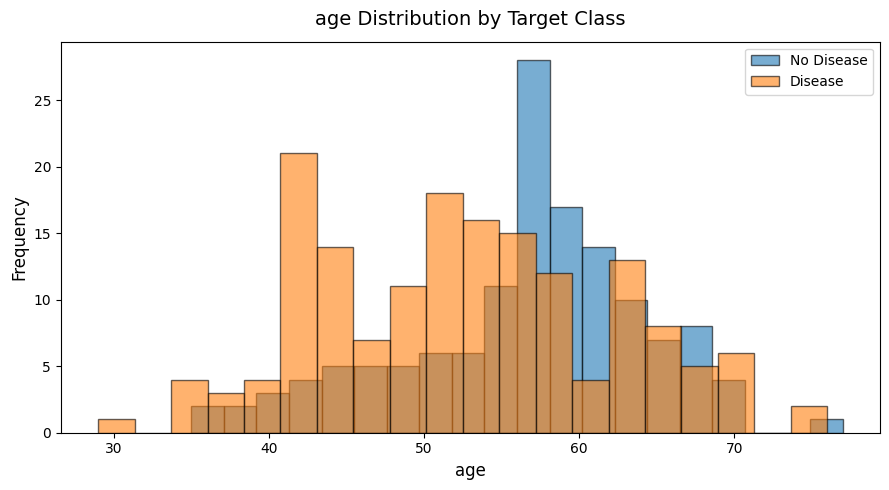

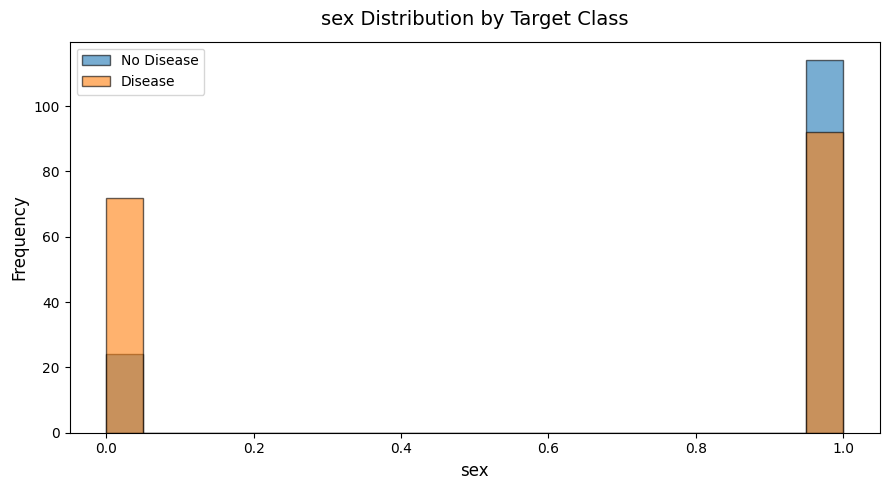

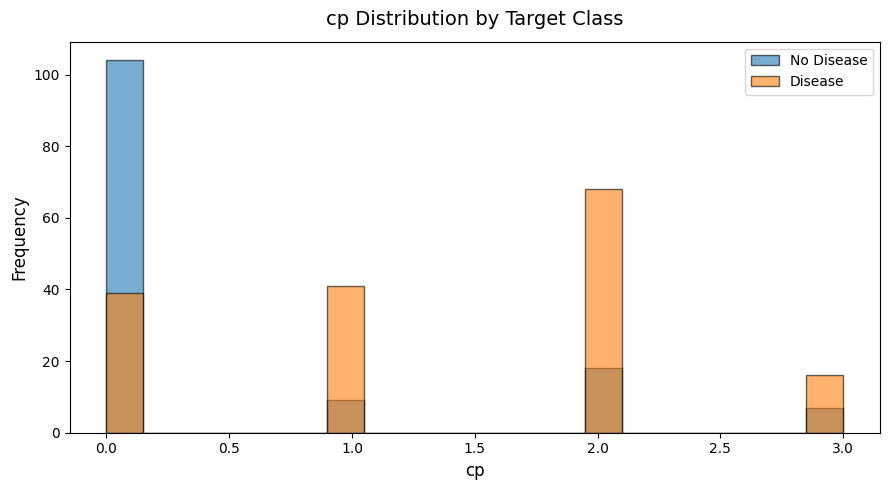

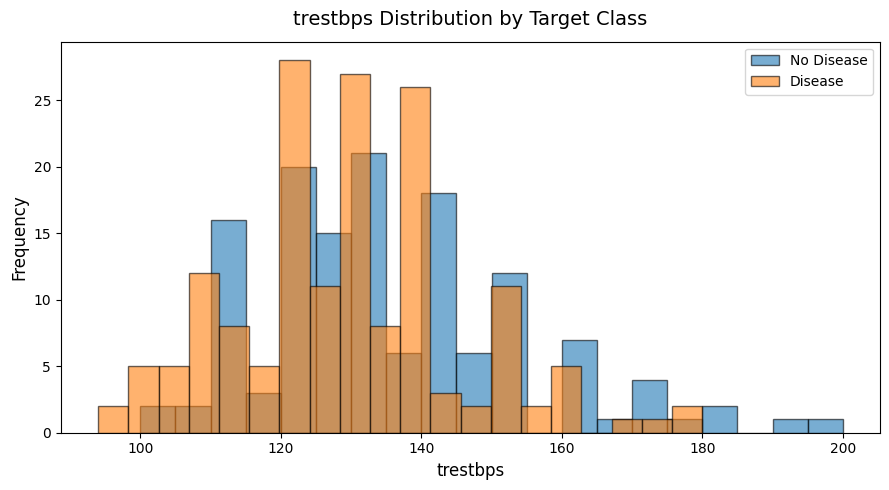

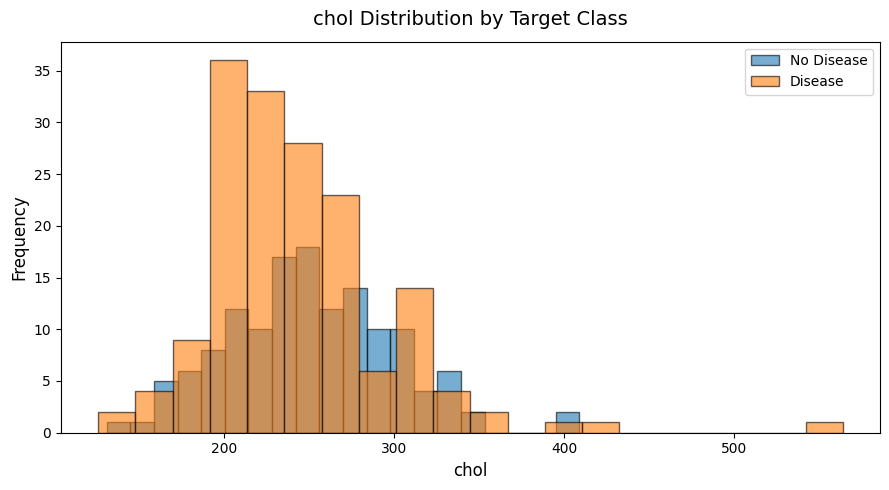

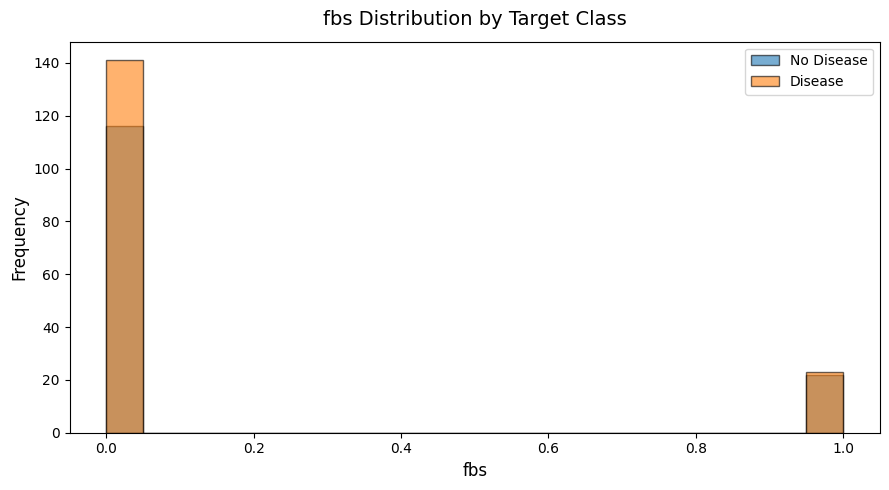

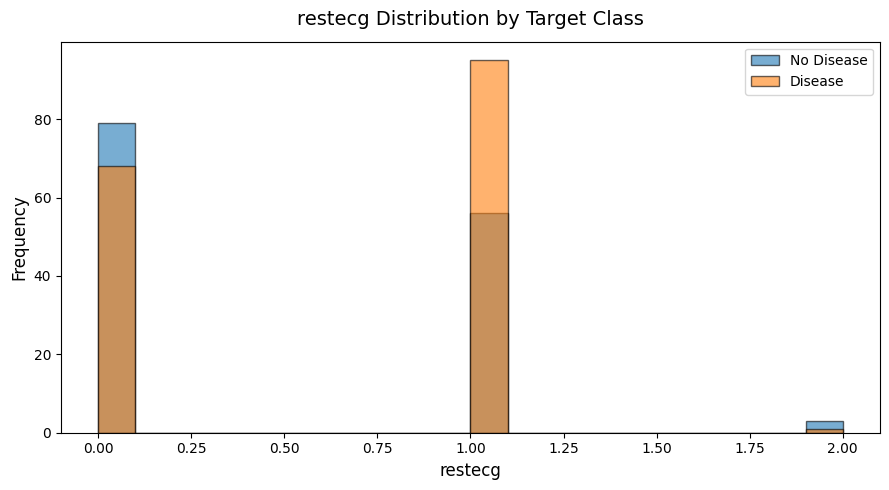

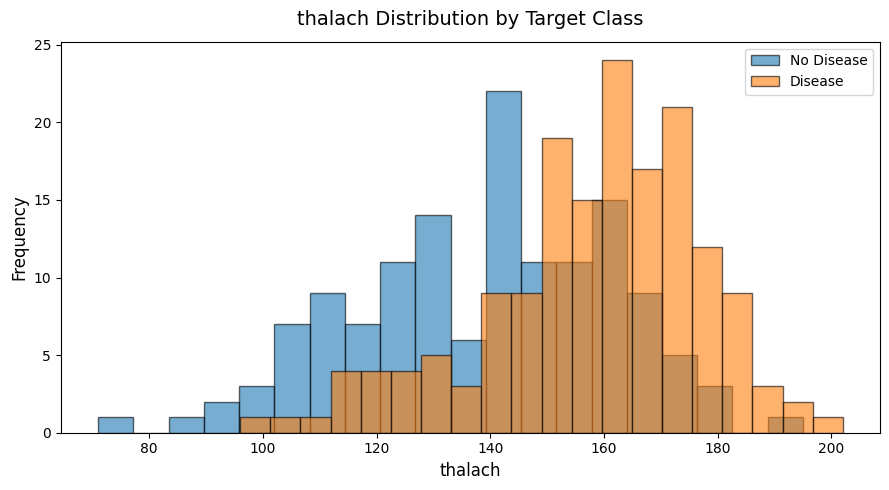

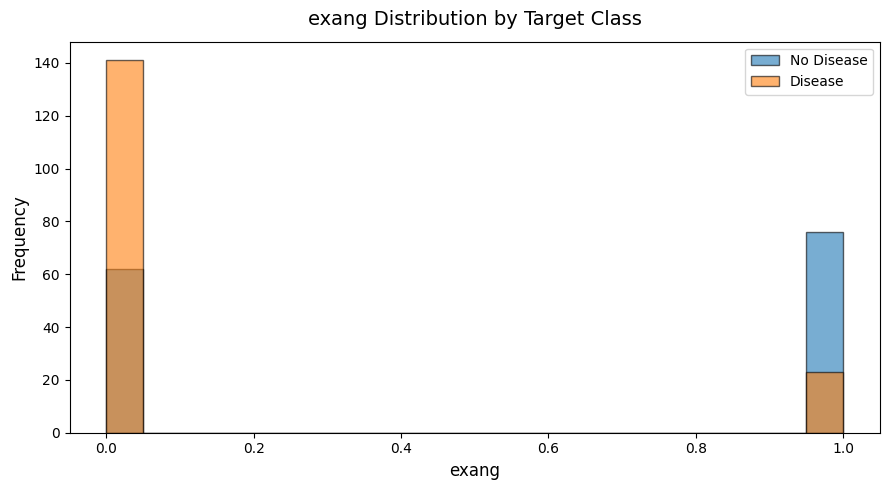

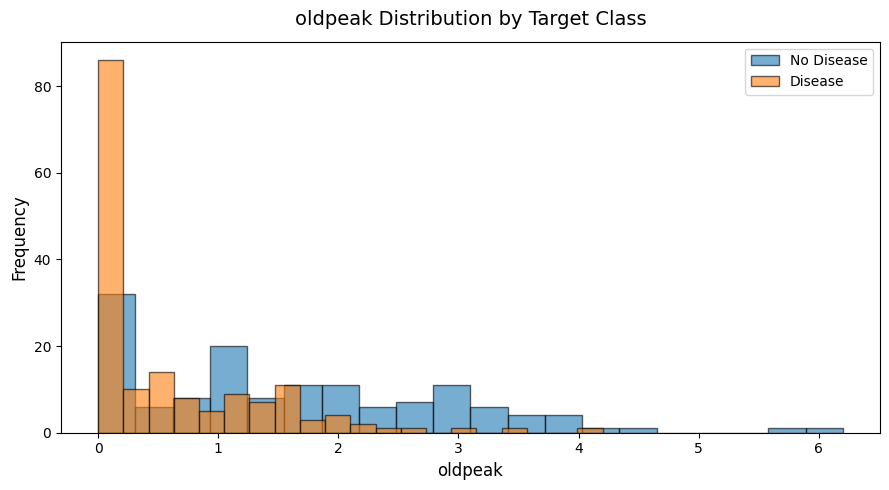

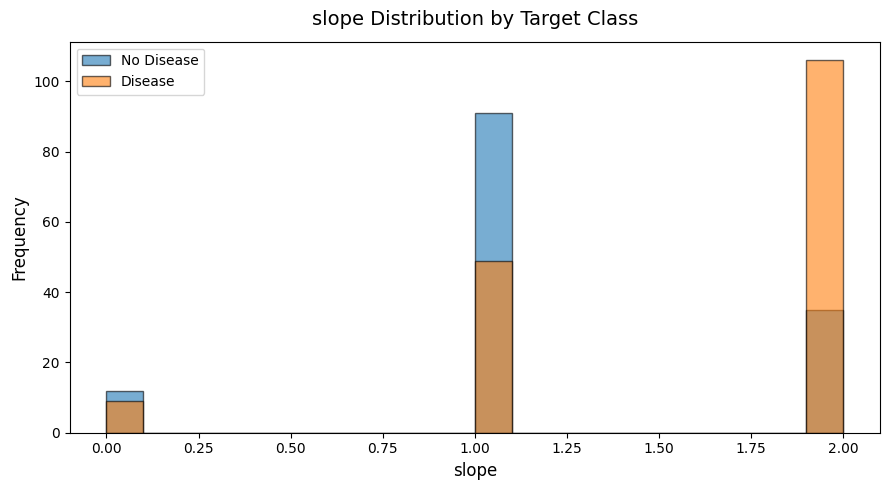

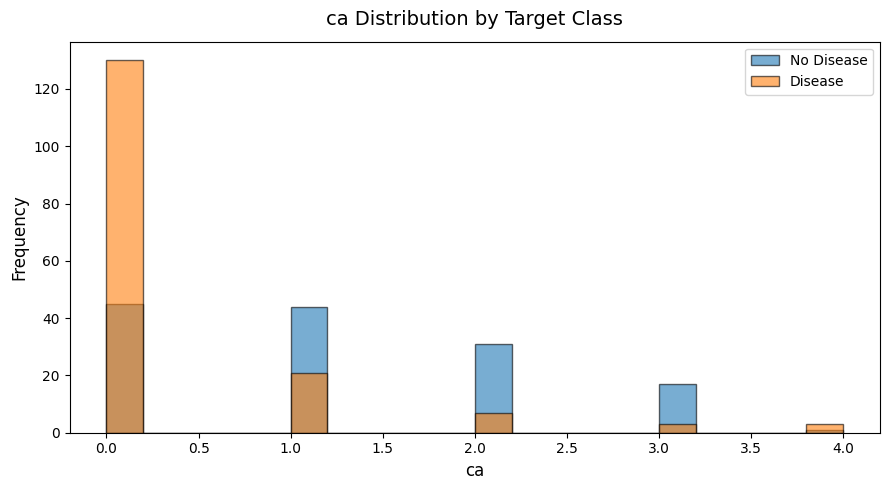

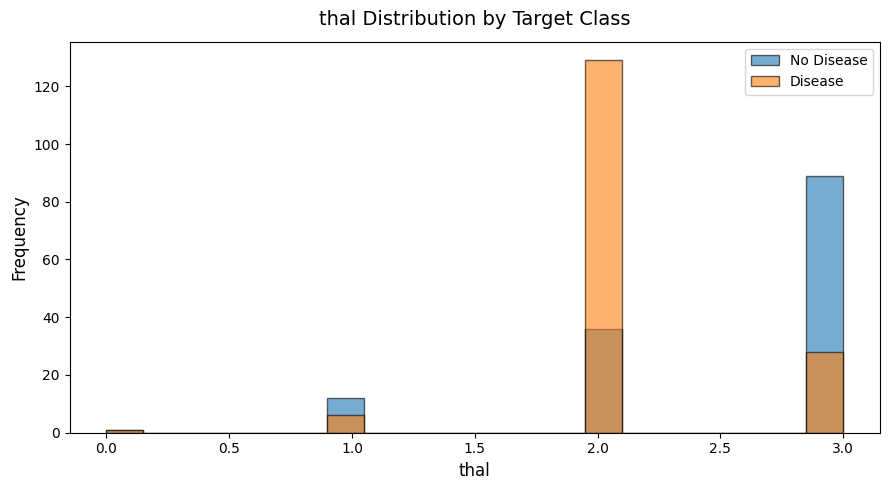

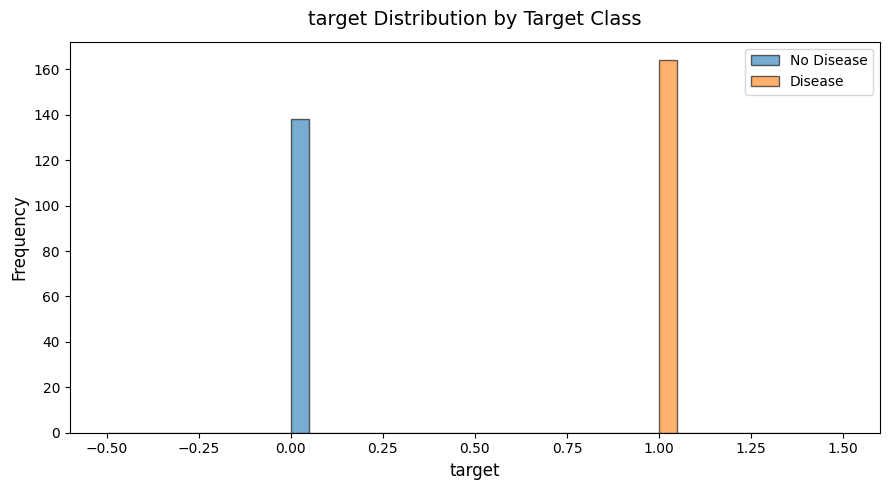

In [28]:
# Clean Class-wise Distribution Comparison

for col in numerical_columns:
    class_0 = []
    class_1 = []

    for i in range(len(df)):
        if df["target"][i] == 0:
            class_0.append(df[col][i])
        else:
            class_1.append(df[col][i])

    plt.figure(figsize=(9, 5))

    plt.hist(
        class_0,
        bins=20,
        alpha=0.6,
        label="No Disease",
        edgecolor='black'
    )
    plt.hist(
        class_1,
        bins=20,
        alpha=0.6,
        label="Disease",
        edgecolor='black'
    )

    plt.title(f"{col} Distribution by Target Class", fontsize=14, pad=12)
    plt.xlabel(col, fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.legend()

    plt.tight_layout()
    plt.show()

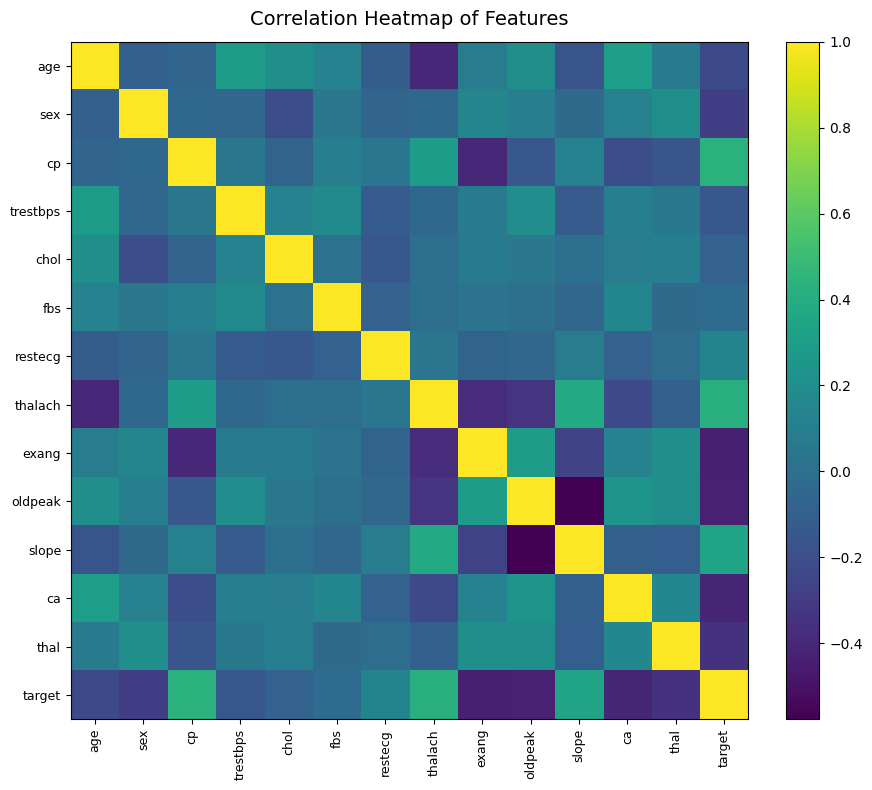

In [29]:
# Clean Correlation Heatmap

corr = df.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr)

plt.colorbar(fraction=0.046, pad=0.04)

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90,
    fontsize=9
)
plt.yticks(
    range(len(corr.columns)),
    corr.columns,
    fontsize=9
)

plt.title("Correlation Heatmap of Features", fontsize=14, pad=12)

plt.tight_layout()
plt.show()

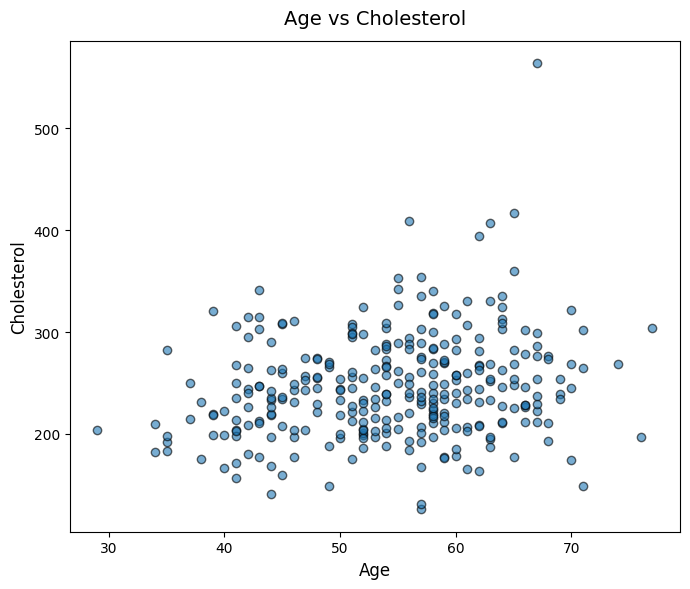

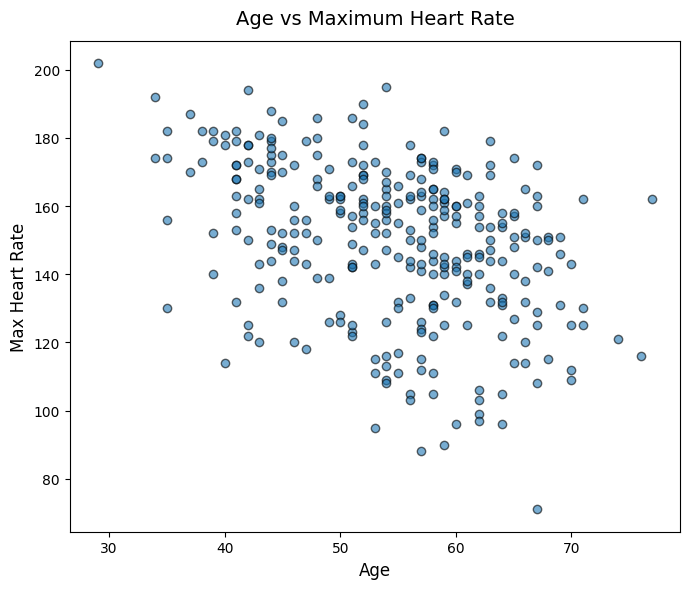

In [30]:
# Clean Scatter Plots for Key Relationships

plt.figure(figsize=(7, 6))
plt.scatter(df["age"], df["chol"], alpha=0.6, edgecolors='black')
plt.title("Age vs Cholesterol", fontsize=14, pad=12)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Cholesterol", fontsize=12)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
plt.scatter(df["age"], df["thalach"], alpha=0.6, edgecolors='black')
plt.title("Age vs Maximum Heart Rate", fontsize=14, pad=12)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Max Heart Rate", fontsize=12)
plt.tight_layout()
plt.show()

In [31]:
# Identify Categorical Columns

categorical_columns = ["sex", "cp", "thal", "slope", "restecg", "ca"]

print("Categorical columns to encode:", categorical_columns)

Categorical columns to encode: ['sex', 'cp', 'thal', 'slope', 'restecg', 'ca']


Manual Category Mapping Generator (Dynamic)

This function:
- Assigns integers dynamically
- Automatically handles unseen categories
- Preserves consistency for future data

In [32]:
# Manual Category Mapping Generator

def generate_category_mapping(values):
    mapping = {}
    current_code = 0

    for v in values:
        if v not in mapping:
            mapping[v] = current_code
            current_code += 1

    return mapping

In [33]:
# Manual Encoding Function

def manual_encode_column(column_values, mapping):
    encoded_values = []
    unknown_code = len(mapping)  # reserve next integer for unknowns

    for v in column_values:
        if v in mapping:
            encoded_values.append(mapping[v])
        else:
            encoded_values.append(unknown_code)

    return encoded_values

This ensures:

- No crashes on unseen categories
- Future data compatibility

In [34]:
# Apply Manual Encoding

category_mappings = {}

for col in categorical_columns:
    values = df[col].tolist()

    mapping = generate_category_mapping(values)
    category_mappings[col] = mapping

    df[col] = manual_encode_column(values, mapping)

    print(f"Encoding applied on '{col}':", mapping)

Encoding applied on 'sex': {1.0: 0, 0.0: 1}
Encoding applied on 'cp': {3.0: 0, 2.0: 1, 1.0: 2, 0.0: 3}
Encoding applied on 'thal': {1.0: 0, 2.0: 1, 3.0: 2, 0.0: 3}
Encoding applied on 'slope': {0.0: 0, 2.0: 1, 1.0: 2}
Encoding applied on 'restecg': {0.0: 0, 1.0: 1, 2.0: 2}
Encoding applied on 'ca': {0.0: 0, 2.0: 1, 1.0: 2, 3.0: 3, 4.0: 4}


In [35]:
# Verify Encoded Columns

df[categorical_columns].head()

,sex,cp,thal,slope,restecg,ca
0,0,0,0,0,0,0
1,0,1,1,0,1,0
2,1,2,1,1,0,0
3,0,2,1,1,1,0
4,1,3,1,1,1,0


In [36]:
# Identify Numerical Columns for Scaling (exclude target)

numerical_columns_for_scaling = []

for col in df.columns:
    if col != "target":
        is_numeric = True
        for v in df[col]:
            if not isinstance(v, (int, float)):
                is_numeric = False
                break
        if is_numeric:
            numerical_columns_for_scaling.append(col)

print("Numerical columns for scaling:", numerical_columns_for_scaling)

Numerical columns for scaling: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [37]:
# Manual Percentile Calculation

def manual_percentile(values, percentile):
    sorted_vals = sorted(values)
    k = (len(sorted_vals) - 1) * (percentile / 100)
    f = int(k)
    c = f + 1

    if c >= len(sorted_vals):
        return sorted_vals[f]

    return sorted_vals[f] + (k - f) * (sorted_vals[c] - sorted_vals[f])

In [38]:
# Robust Scaling Using Median and IQR

def robust_scale(values):
    median_val = manual_median(values)
    q1 = manual_percentile(values, 25)
    q3 = manual_percentile(values, 75)
    iqr = q3 - q1

    scaled = []
    for v in values:
        if iqr != 0:
            scaled.append((v - median_val) / iqr)
        else:
            scaled.append(0)

    return scaled

Why this is robust:

- Median resists outliers
- IQR controls skew
- Stable for medical distributions

In [39]:
# Apply Robust Scaling to Numerical Columns

for col in numerical_columns_for_scaling:
    df[col] = robust_scale(df[col].tolist())

df[numerical_columns_for_scaling].head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,0.576923,0.0,-1.0,0.75,-0.117647,0,-1.0,-0.076336,0.0,0.9375,-1.0,0.0,-1.0
1,-1.423077,0.0,-0.5,0.00,0.149020,0,0.0,1.053435,0.0,1.6875,-1.0,0.0,0.0
2,-1.115385,1.0,0.0,0.00,-0.572549,0,-1.0,0.595420,0.0,0.3750,0.0,0.0,0.0
3,0.038462,0.0,0.0,-0.50,-0.070588,0,0.0,0.778626,0.0,0.0000,0.0,0.0,0.0
4,0.115385,1.0,0.5,-0.50,1.780392,0,0.0,0.320611,1.0,-0.1250,0.0,0.0,0.0


In [40]:
# Post-Scaling Check

for col in numerical_columns_for_scaling:
    values = df[col].tolist()
    print(
        col,
        "min:", round(manual_min(values), 3),
        "max:", round(manual_max(values), 3),
        "median:", round(manual_median(values), 3)
    )

age min: -2.038 max: 1.654 median: 0.0
sex min: 0.0 max: 1.0 median: 0.0
cp min: -1.0 max: 0.5 median: 0.0
trestbps min: -1.8 max: 3.5 median: 0.0
chol min: -1.796 max: 5.075 median: 0.0
fbs min: 0 max: 0 median: 0.0
restecg min: -1.0 max: 1.0 median: 0.0
thalach min: -2.489 max: 1.511 median: 0.0
exang min: 0.0 max: 1.0 median: 0.0
oldpeak min: -0.5 max: 3.375 median: 0.0
slope min: -1.0 max: 1.0 median: 0.0
ca min: 0.0 max: 2.0 median: 0.0
thal min: -1.0 max: 2.0 median: 0.0


Define Manual One-Hot Encoder (Dynamic)

This encoder:
- Discovers categories at runtime
- Creates binary columns manually
- Safely handles unseen categories in future data

In [41]:
# Manual One-Hot Encoder (Dynamic)

def manual_one_hot_encode(column_name, column_values):
    unique_categories = []
    
    # Identify unique categories manually
    for v in column_values:
        if v not in unique_categories:
            unique_categories.append(v)
    
    # Create one-hot encoded columns
    encoded_columns = {}
    for category in unique_categories:
        encoded_columns[f"{column_name}_{category}"] = []
    
    # Populate encoded values
    for v in column_values:
        for category in unique_categories:
            if v == category:
                encoded_columns[f"{column_name}_{category}"].append(1)
            else:
                encoded_columns[f"{column_name}_{category}"].append(0)
    
    return encoded_columns

We will replace categorical columns with their one-hot representations.

In [42]:
# Apply Manual One-Hot Encoding

one_hot_encoded_data = {}

for col in categorical_columns:
    encoded = manual_one_hot_encode(col, df[col].tolist())
    
    for new_col, values in encoded.items():
        one_hot_encoded_data[new_col] = values

print("One-hot encoded columns created:", list(one_hot_encoded_data.keys())[:5])

One-hot encoded columns created: ['sex_0.0', 'sex_1.0', 'cp_-1.0', 'cp_-0.5', 'cp_0.0']


In [43]:
# Rebuild DataFrame with One-Hot Encoded Columns

processed_data = {}

# Add numerical columns
for col in numerical_columns_for_scaling:
    processed_data[col] = df[col].tolist()

# Add one-hot encoded categorical columns
for col, values in one_hot_encoded_data.items():
    processed_data[col] = values

# Add target column
processed_data["target"] = df["target"].tolist()

df_processed = pd.DataFrame(processed_data)
df_processed.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,...,slope_1.0,restecg_-1.0,restecg_0.0,restecg_1.0,ca_0.0,ca_0.5,ca_1.0,ca_1.5,ca_2.0,target
0,0.576923,0.0,-1.0,0.75,-0.117647,0,-1.0,-0.076336,0.0,0.9375,...,0,1,0,0,1,0,0,0,0,1.0
1,-1.423077,0.0,-0.5,0.00,0.149020,0,0.0,1.053435,0.0,1.6875,...,0,0,1,0,1,0,0,0,0,1.0
2,-1.115385,1.0,0.0,0.00,-0.572549,0,-1.0,0.595420,0.0,0.3750,...,0,1,0,0,1,0,0,0,0,1.0
3,0.038462,0.0,0.0,-0.50,-0.070588,0,0.0,0.778626,0.0,0.0000,...,0,0,1,0,1,0,0,0,0,1.0
4,0.115385,1.0,0.5,-0.50,1.780392,0,0.0,0.320611,1.0,-0.1250,...,0,0,1,0,1,0,0,0,0,1.0


In [44]:
# Verification Checks

print("Original shape:", df.shape)
print("Processed shape:", df_processed.shape)

Original shape: (302, 14)
Processed shape: (302, 35)


We use scaled values from df_processed.

In [45]:
# Extract Required Columns for Risk Factor

chol_values = df_processed["chol"].tolist()
thalach_values = df_processed["thalach"].tolist()

In [46]:
# Manual Percentile Rank Function

def percentile_rank(values, value):
    count = 0
    for v in values:
        if v <= value:
            count += 1
    return count / len(values)

Domain reasoning:

- High cholesterol → increases risk
- Low max heart rate → increases risk
- Interaction term captures combined stress
- Percentile boosts relative severity

Mathematical structure:

risk_factor = 
(0.4∗chol_percentile)+(0.4∗(1−thalach_percentile))+(0.2∗interaction)

Where:  interaction=chol×(1−thalach)

In [47]:
# Create Risk Factor Feature

risk_factor = []

for i in range(len(df_processed)):
    chol = chol_values[i]
    thalach = thalach_values[i]
    
    chol_pct = percentile_rank(chol_values, chol)
    thalach_pct = percentile_rank(thalach_values, thalach)
    
    interaction = chol * (1 - thalach)
    
    risk_score = (
        0.4 * chol_pct +
        0.4 * (1 - thalach_pct) +
        0.2 * interaction
    )
    
    risk_factor.append(risk_score)

df_processed["risk_factor"] = risk_factor

df_processed[["chol", "thalach", "risk_factor"]].head()

,chol,thalach,risk_factor
0,-0.117647,-0.076336,0.364078
1,0.149020,1.053435,0.239467
2,-0.572549,0.595420,0.096718
3,-0.070588,0.778626,0.218067
4,1.780392,0.320611,0.745227


In [48]:
# Normalize Risk Factor Between 0 and 1

min_risk = manual_min(risk_factor)
max_risk = manual_max(risk_factor)

normalized_risk = []

for r in risk_factor:
    if max_risk - min_risk != 0:
        normalized_risk.append((r - min_risk) / (max_risk - min_risk))
    else:
        normalized_risk.append(0)

df_processed["risk_factor"] = normalized_risk

In [49]:
# Risk Factor Summary

print("Risk Factor Min:", round(manual_min(normalized_risk), 3))
print("Risk Factor Max:", round(manual_max(normalized_risk), 3))
print("Risk Factor Median:", round(manual_median(normalized_risk), 3))

Risk Factor Min: 0.0
Risk Factor Max: 1.0
Risk Factor Median: 0.429


In [50]:
# Prepare CSV Header and Rows (Manual)

output_path = "../data/heart_processed.csv"

columns = df_processed.columns.tolist()

rows_as_strings = []

# Header
header_line = ",".join(columns)
rows_as_strings.append(header_line)

# Data rows
for i in range(len(df_processed)):
    row_values = []
    for col in columns:
        row_values.append(str(df_processed[col][i]))
    rows_as_strings.append(",".join(row_values))

In [51]:
# Write CSV File Manually

with open(output_path, "w") as f:
    for line in rows_as_strings:
        f.write(line + "\n")

print("Processed data written to:", output_path)

Processed data written to: ../data/heart_processed.csv


In [52]:
# Verification: Read First Few Lines Manually

with open(output_path, "r") as f:
    for _ in range(5):
        print(f.readline().strip())

age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,sex_0.0,sex_1.0,cp_-1.0,cp_-0.5,cp_0.0,cp_0.5,thal_-1.0,thal_0.0,thal_1.0,thal_2.0,slope_-1.0,slope_0.0,slope_1.0,restecg_-1.0,restecg_0.0,restecg_1.0,ca_0.0,ca_0.5,ca_1.0,ca_1.5,ca_2.0,target,risk_factor
0.5769230769230769,0.0,-1.0,0.75,-0.11764705882352941,0,-1.0,-0.07633587786259542,0.0,0.9374999999999998,-1.0,0.0,-1.0,1,0,1,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,1.0,0.4290321295121858
-1.4230769230769231,0.0,-0.5,0.0,0.14901960784313725,0,0.0,1.0534351145038168,0.0,1.6875,-1.0,0.0,0.0,1,0,0,1,0,0,0,1,0,0,1,0,0,0,1,0,1,0,0,0,0,1.0,0.35659473079254633
-1.1153846153846154,1.0,0.0,0.0,-0.5725490196078431,0,-1.0,0.5954198473282443,0.0,0.3749999999999999,0.0,0.0,0.0,0,1,0,0,1,0,0,1,0,0,0,1,0,1,0,0,1,0,0,0,0,1.0,0.27361379113206813
0.038461538461538464,0.0,0.0,-0.5,-0.07058823529411765,0,0.0,0.7786259541984732,0.0,0.0,0.0,0.0,0.0,1,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,1,0,0,0,0,1.0,0.34415462661513563


Manual Histogram (Manual Binning + Frequency Calculation)

In [53]:
# Manual Histogram Binning Function

def manual_histogram(values, num_bins=10):
    min_val = manual_min(values)
    max_val = manual_max(values)
    
    bin_width = (max_val - min_val) / num_bins
    bins = []
    frequencies = [0] * num_bins
    
    # Create bin edges
    for i in range(num_bins + 1):
        bins.append(min_val + i * bin_width)
    
    # Count frequencies manually
    for v in values:
        for i in range(num_bins):
            if bins[i] <= v < bins[i + 1]:
                frequencies[i] += 1
                break
            # Include max value in last bin
            if v == max_val and i == num_bins - 1:
                frequencies[i] += 1
    
    return bins, frequencies

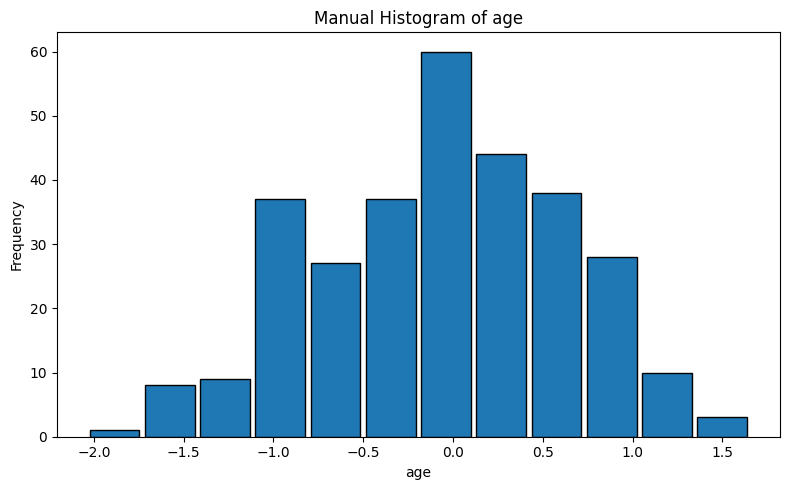

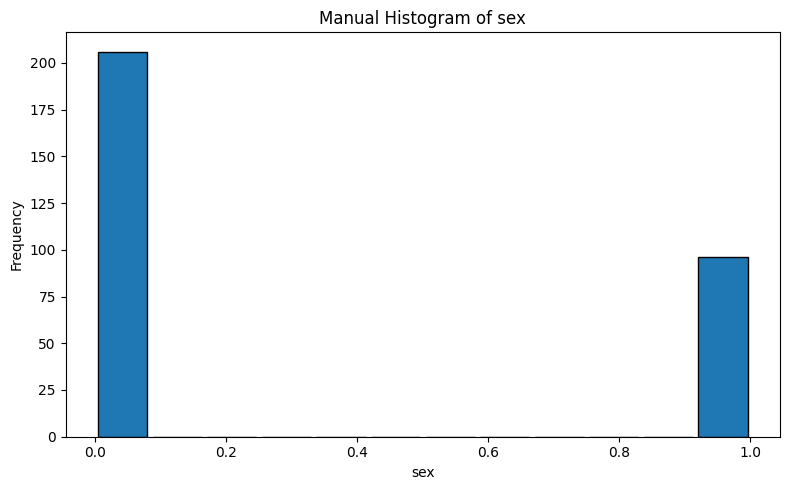

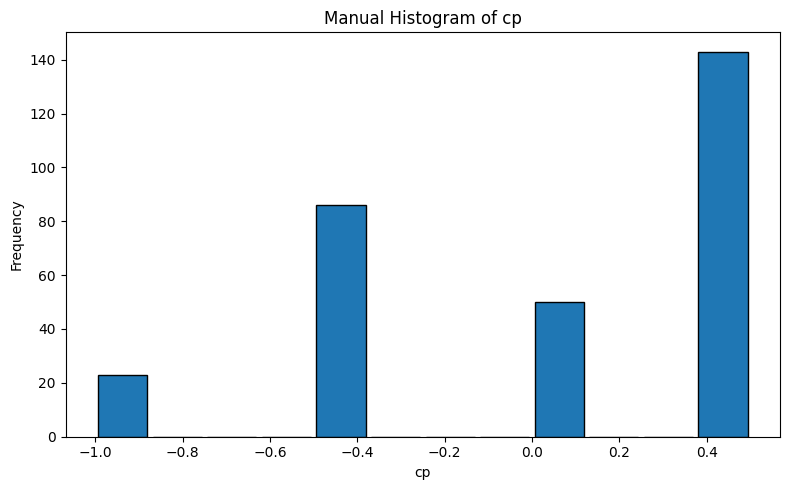

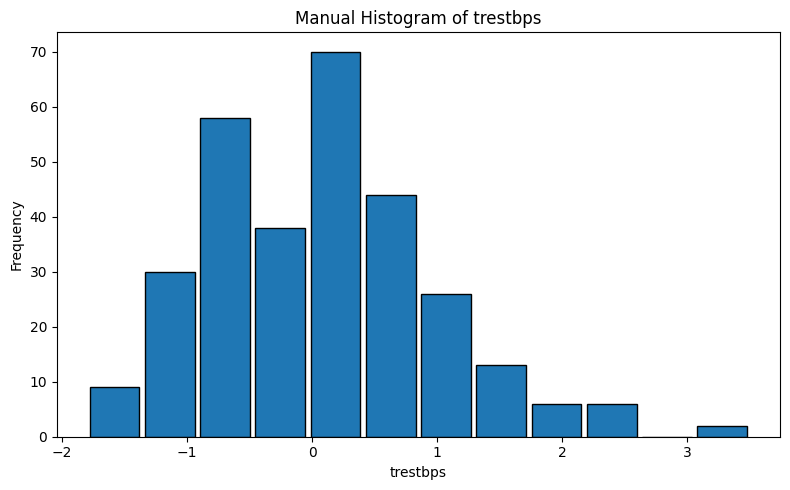

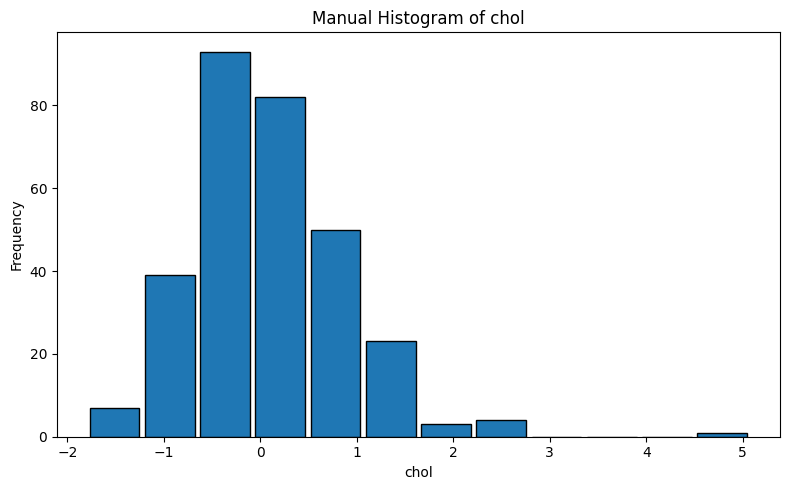

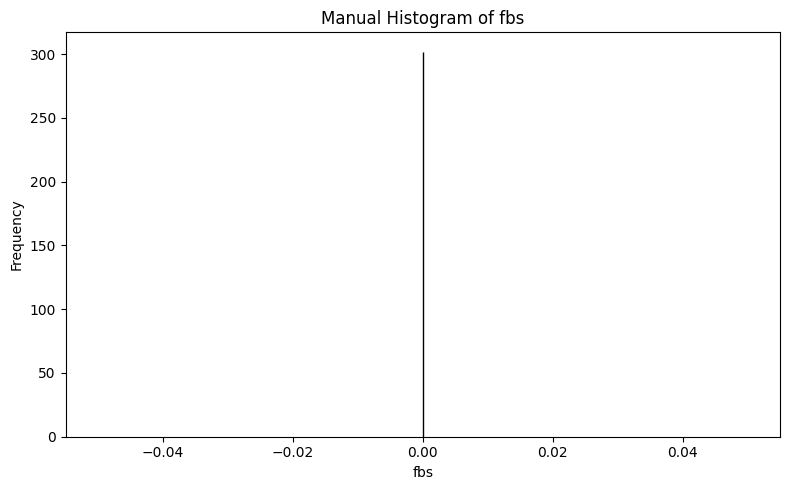

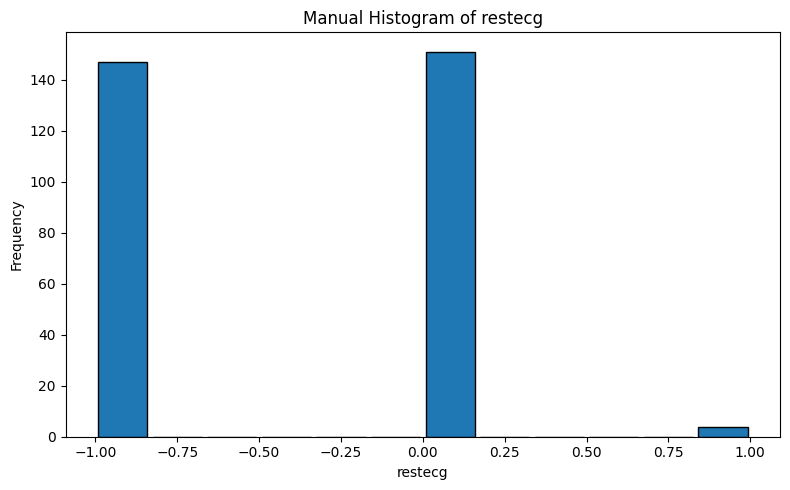

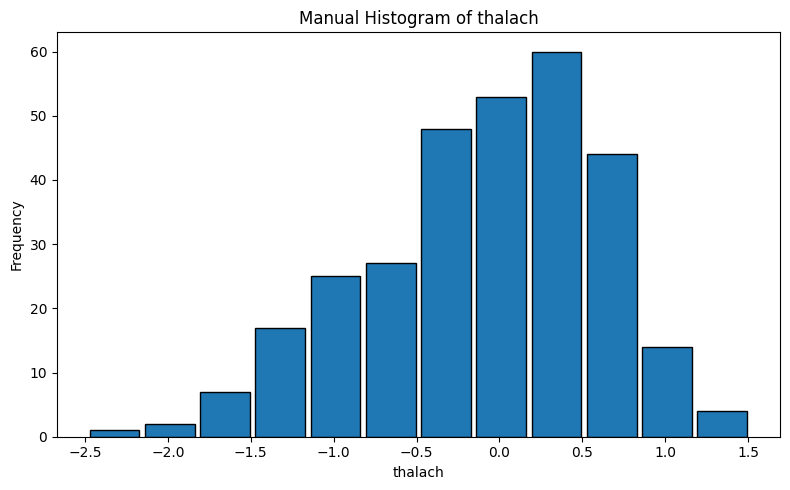

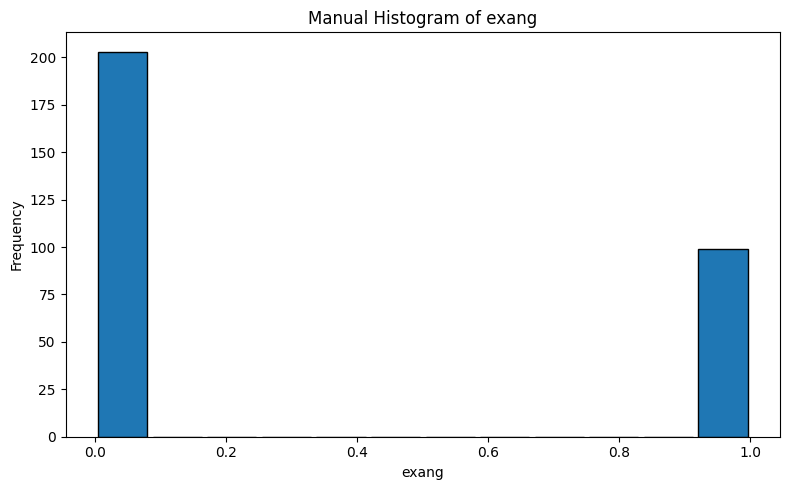

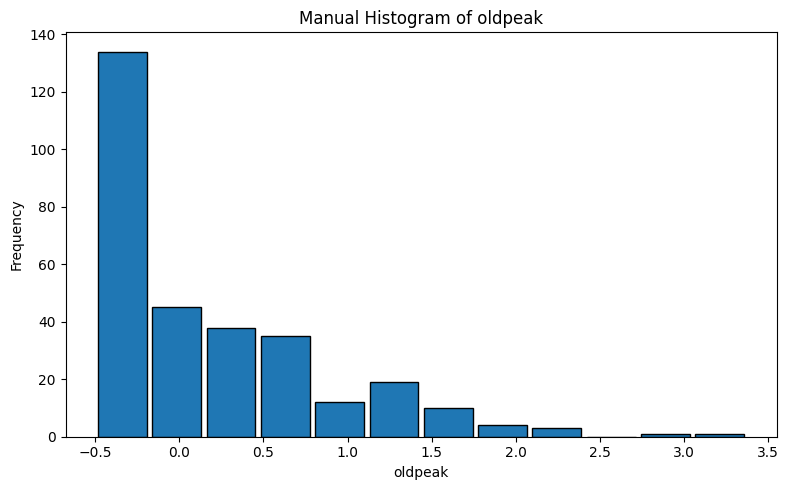

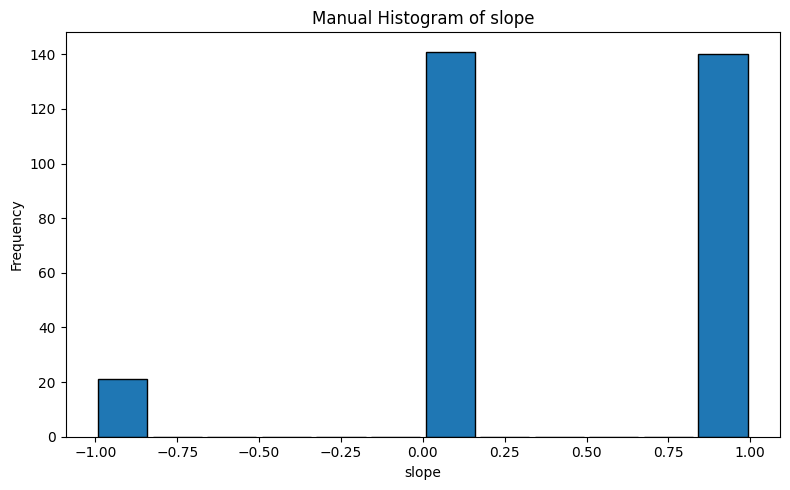

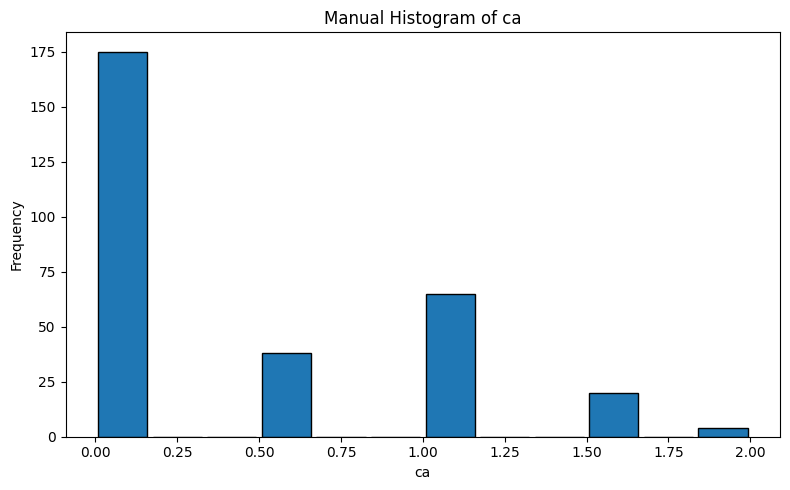

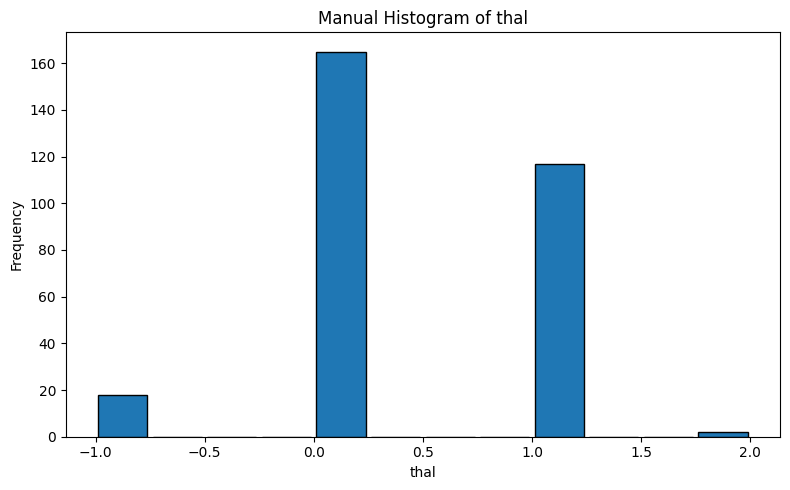

In [54]:
# Plot Manual Histograms

for col in numerical_columns_for_scaling:
    values = df_processed[col].tolist()
    
    bins, frequencies = manual_histogram(values, num_bins=12)
    
    bin_centers = []
    bin_width = bins[1] - bins[0]
    
    for i in range(len(bins) - 1):
        bin_centers.append(bins[i] + bin_width / 2)
    
    plt.figure(figsize=(8, 5))
    
    plt.bar(
        bin_centers,
        frequencies,
        width=bin_width * 0.9,
        edgecolor='black'
    )
    
    plt.title(f"Manual Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    
    plt.tight_layout()
    plt.show()

In [55]:
# Manual Quartile & IQR Calculation

def manual_quartiles(values):
    sorted_vals = sorted(values)
    q1 = manual_percentile(sorted_vals, 25)
    q2 = manual_median(sorted_vals)
    q3 = manual_percentile(sorted_vals, 75)
    iqr = q3 - q1
    return q1, q2, q3, iqr

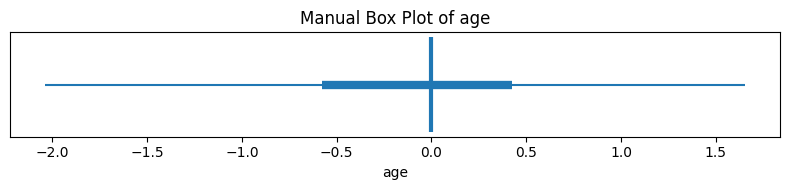

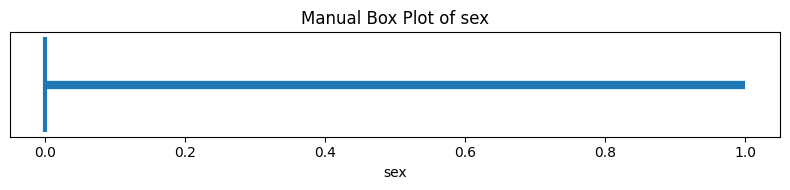

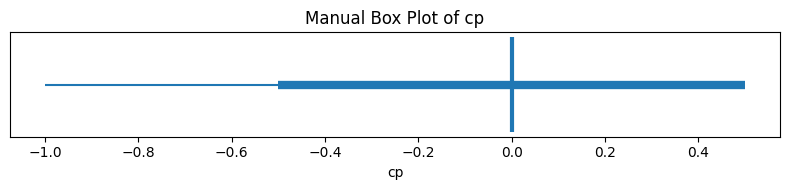

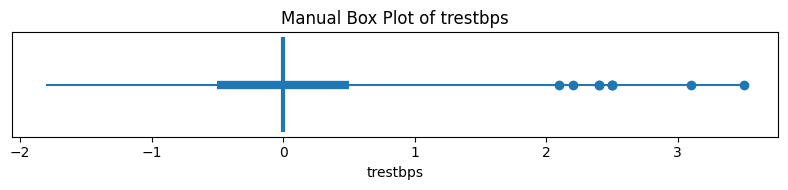

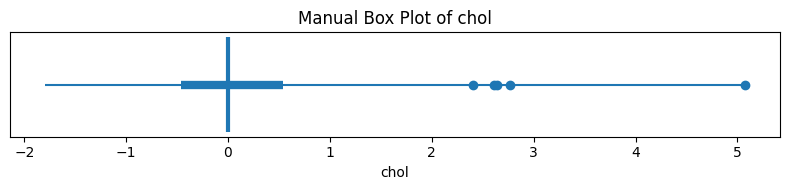

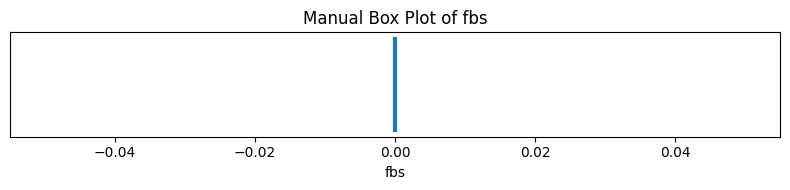

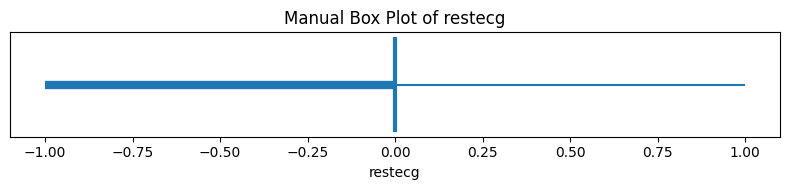

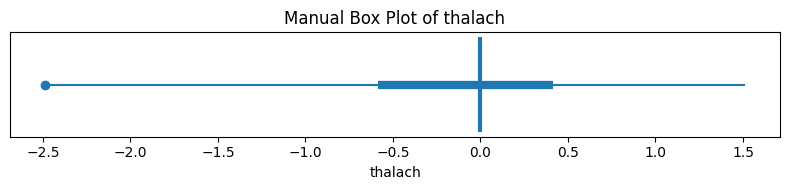

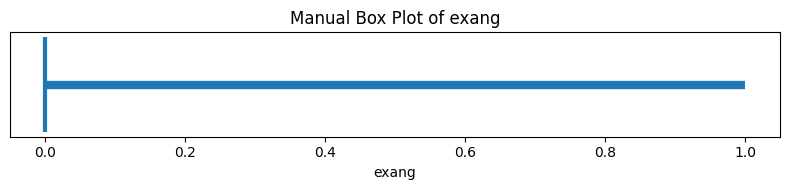

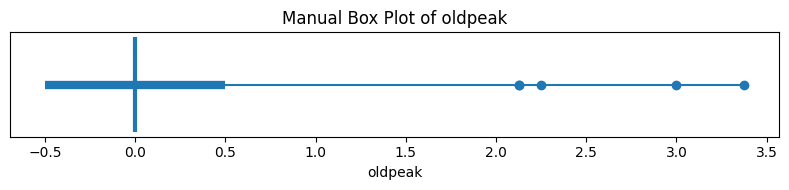

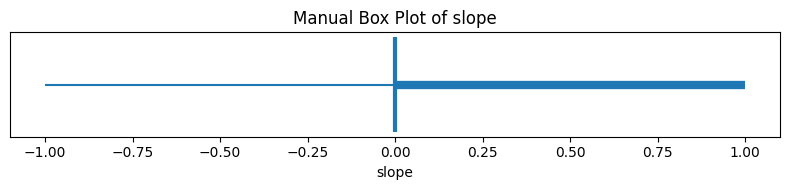

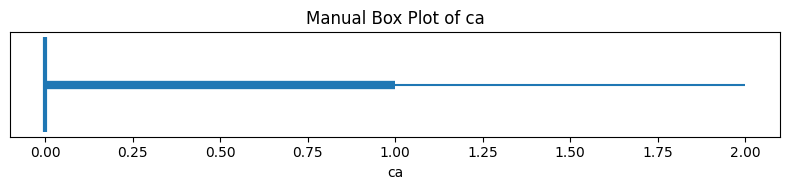

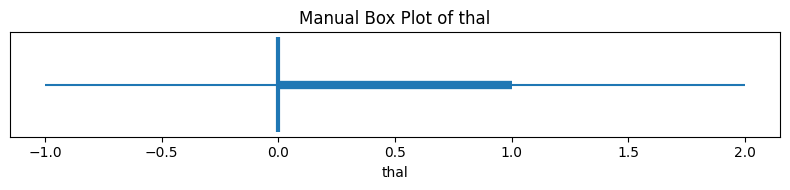

In [56]:
# Manual Box Plot Drawing

for col in numerical_columns_for_scaling:
    values = df_processed[col].tolist()
    q1, median, q3, iqr = manual_quartiles(values)
    
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr
    
    plt.figure(figsize=(8, 2))
    
    # Box
    plt.hlines(1, q1, q3, linewidth=6)
    
    # Median
    plt.vlines(median, 0.95, 1.05, linewidth=3)
    
    # Whiskers
    plt.hlines(1, manual_min(values), q1)
    plt.hlines(1, q3, manual_max(values))
    
    # Outliers
    outliers = [v for v in values if v < lower_fence or v > upper_fence]
    plt.scatter(outliers, [1]*len(outliers))
    
    plt.title(f"Manual Box Plot of {col}")
    plt.yticks([])
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

In [57]:
# Manual Frequency Counter

def manual_frequency(values):
    freq = {}
    for v in values:
        if v in freq:
            freq[v] += 1
        else:
            freq[v] = 1
    return freq

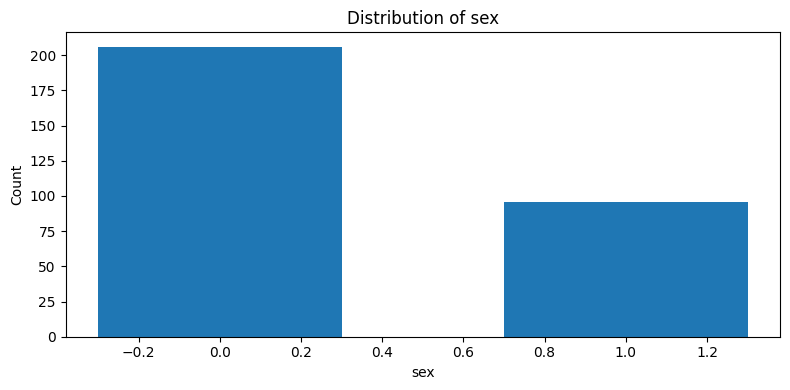

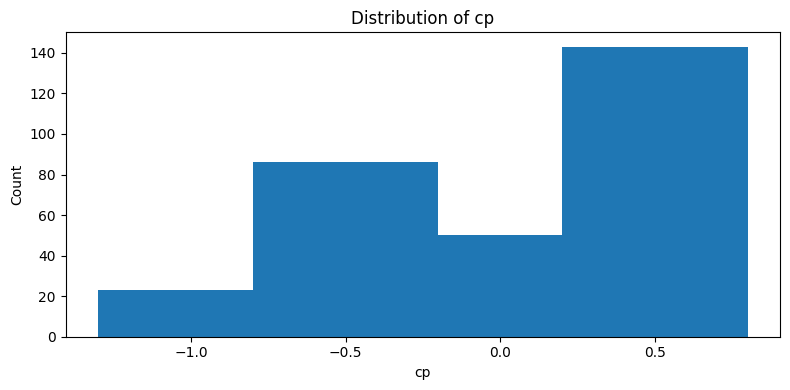

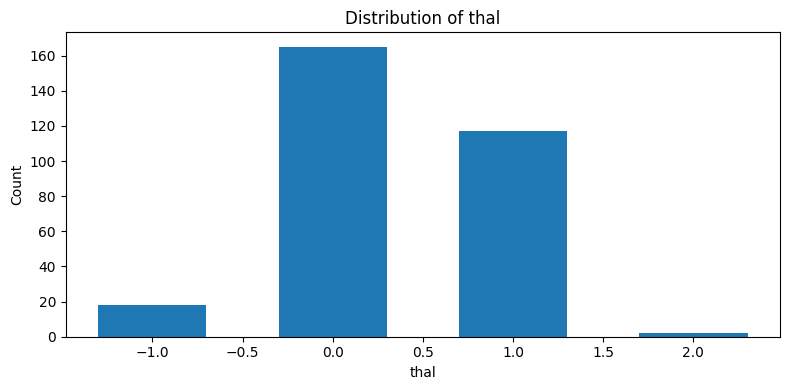

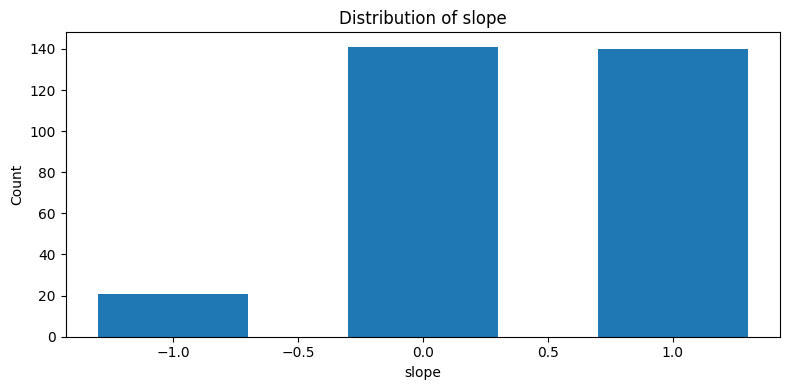

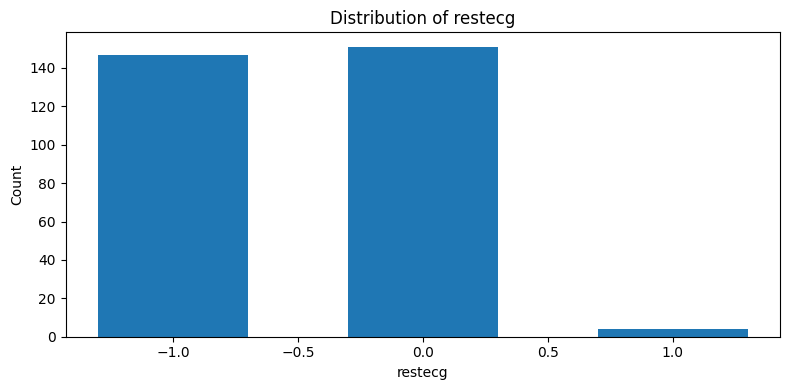

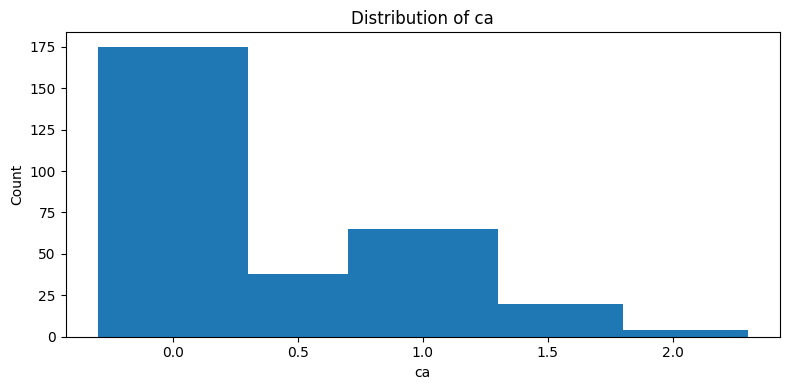

In [58]:
# Manual Bar Plots for Categorical Columns

for col in categorical_columns:
    values = df[col].tolist()
    freq = manual_frequency(values)
    
    categories = list(freq.keys())
    counts = list(freq.values())
    
    plt.figure(figsize=(8, 4))
    plt.bar(categories, counts, width=0.6)
    
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    
    plt.tight_layout()
    plt.show()

In [59]:
# Manual Missing Value Grid

missing_grid = []

for _, row in df.iterrows():
    row_mask = []
    for value in row:
        row_mask.append(1 if is_missing(value) else 0)
    missing_grid.append(row_mask)

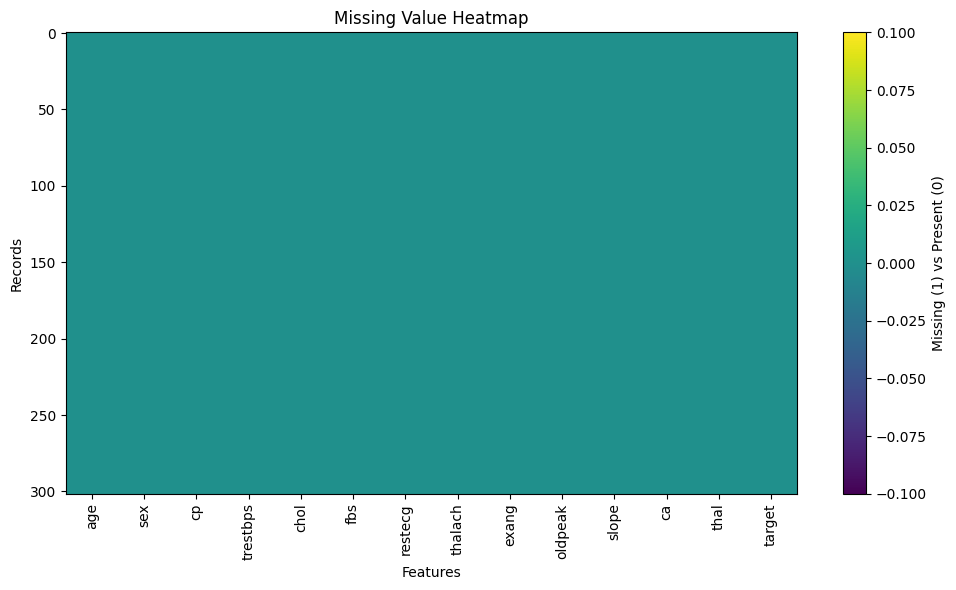

In [60]:
# Manual Missing Value Heatmap

plt.figure(figsize=(10, 6))
plt.imshow(missing_grid, aspect='auto')

plt.colorbar(label="Missing (1) vs Present (0)")
plt.title("Missing Value Heatmap")
plt.xlabel("Features")
plt.ylabel("Records")

plt.xticks(range(len(df.columns)), df.columns, rotation=90)
plt.tight_layout()
plt.show()

In [61]:
# Manual Correlation Coefficient

def manual_correlation(x, y):
    mean_x = manual_mean(x)
    mean_y = manual_mean(y)
    
    num = 0
    den_x = 0
    den_y = 0
    
    for i in range(len(x)):
        dx = x[i] - mean_x
        dy = y[i] - mean_y
        num += dx * dy
        den_x += dx ** 2
        den_y += dy ** 2
    
    # Handle zero variance case
    if den_x == 0 or den_y == 0:
        return 0  # correlation undefined → treat as no correlation
    
    return num / ((den_x ** 0.5) * (den_y ** 0.5))

In [62]:
# Select Highly Correlated Feature Pairs

correlated_pairs = []

for i in range(len(numerical_columns_for_scaling)):
    for j in range(i+1, len(numerical_columns_for_scaling)):
        col1 = numerical_columns_for_scaling[i]
        col2 = numerical_columns_for_scaling[j]
        
        corr = manual_correlation(
            df_processed[col1].tolist(),
            df_processed[col2].tolist()
        )
        
        if abs(corr) > 0.5:
            correlated_pairs.append((col1, col2, corr))

In [63]:
# Manual Pair Plots with Trendlines

for col1, col2, corr in correlated_pairs:
    x = df_processed[col1].tolist()
    y = df_processed[col2].tolist()
    
    mean_x = manual_mean(x)
    mean_y = manual_mean(y)
    
    slope = sum((x[i]-mean_x)*(y[i]-mean_y) for i in range(len(x))) / \
            sum((x[i]-mean_x)**2 for i in range(len(x)))
    
    intercept = mean_y - slope * mean_x
    
    plt.figure(figsize=(6, 5))
    plt.scatter(x, y, alpha=0.6)
    
    trend_y = [slope * xi + intercept for xi in x]
    plt.plot(x, trend_y)
    
    plt.title(f"{col1} vs {col2} (corr={corr:.2f})")
    plt.xlabel(col1)
    plt.ylabel(col2)
    
    plt.tight_layout()
    plt.show()

In [64]:
# Manual Correlation Matrix

def compute_correlation_matrix(dataframe, columns):
    matrix = []
    
    for col1 in columns:
        row = []
        for col2 in columns:
            corr = manual_correlation(
                dataframe[col1].tolist(),
                dataframe[col2].tolist()
            )
            row.append(corr)
        matrix.append(row)
    
    return matrix

corr_matrix = compute_correlation_matrix(
    df_processed,
    numerical_columns_for_scaling
)

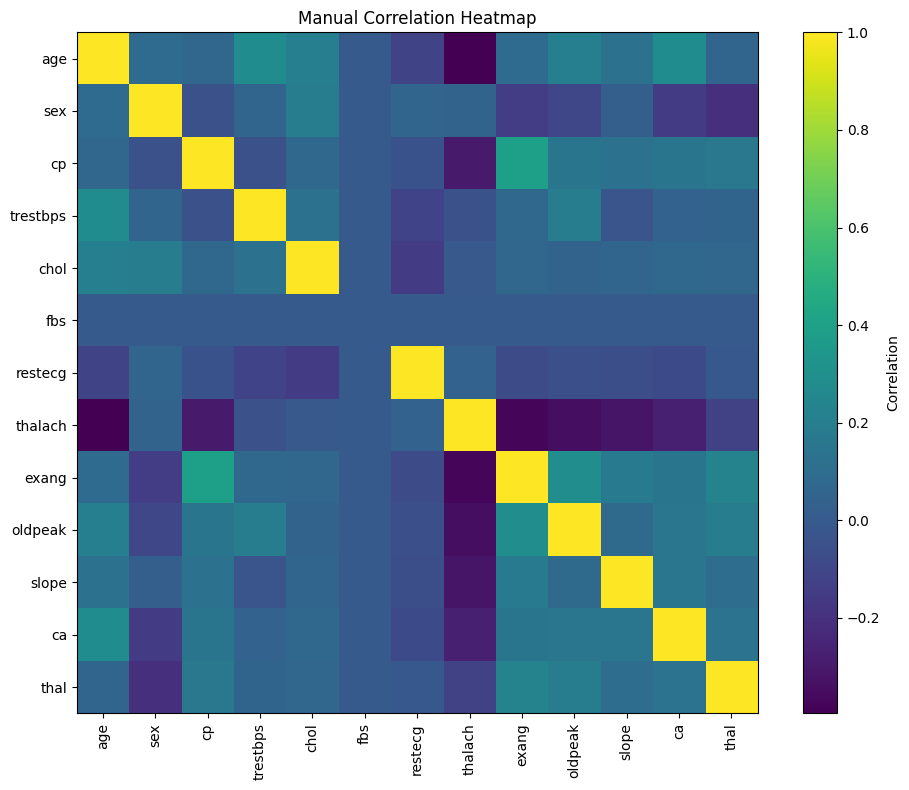

In [65]:
# Custom Correlation Heatmap

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(numerical_columns_for_scaling)),
    numerical_columns_for_scaling,
    rotation=90
)
plt.yticks(
    range(len(numerical_columns_for_scaling)),
    numerical_columns_for_scaling
)

plt.title("Manual Correlation Heatmap")
plt.tight_layout()
plt.show()

Scatter Plot with Dynamic Size & Color

In [66]:
# Dynamic Scatter Plot Function

def dynamic_scatter(x, y, size_attr, color_attr, xlabel, ylabel):
    sizes = []
    colors = []
    
    for i in range(len(x)):
        sizes.append(20 + size_attr[i] * 20)
        colors.append(color_attr[i])
    
    plt.figure(figsize=(7, 6))
    plt.scatter(x, y, s=sizes, c=colors, alpha=0.6)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(f"{xlabel} vs {ylabel}")
    plt.tight_layout()
    plt.show()

Chol vs Thalach (Age = size, Target = color)

c:\HeartGuard\venv\Lib\site-packages\matplotlib\collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


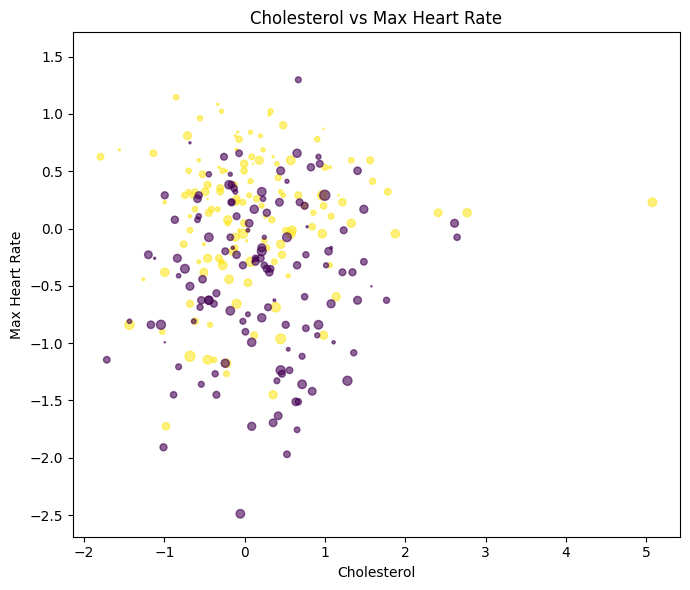

In [67]:
dynamic_scatter(
    df_processed["chol"].tolist(),
    df_processed["thalach"].tolist(),
    df["age"].tolist(),
    df_processed["target"].tolist(),
    "Cholesterol",
    "Max Heart Rate"
)

Manual Violin Plot (KDE-Based)

In [68]:
# Manual KDE Function

def manual_kde(values, points=100):
    min_val = manual_min(values)
    max_val = manual_max(values)
    step = (max_val - min_val) / points
    
    x_vals = []
    densities = []
    
    for i in range(points):
        x = min_val + i * step
        density = 0
        for v in values:
            density += 1 / (1 + (x - v)**2)
        x_vals.append(x)
        densities.append(density)
    
    return x_vals, densities

Violin Plot vs Target

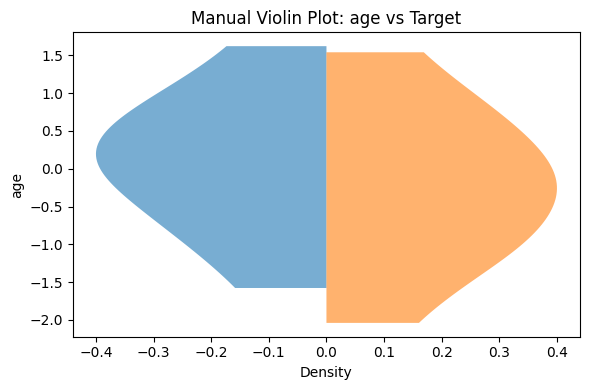

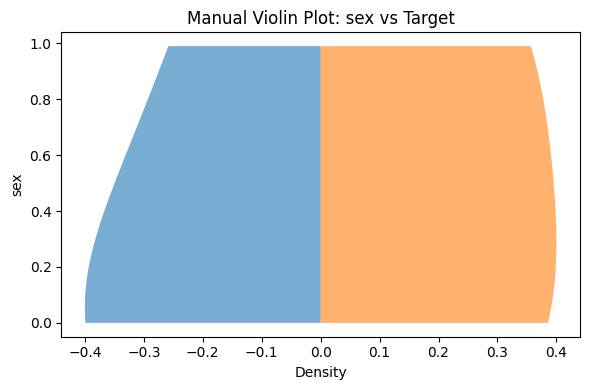

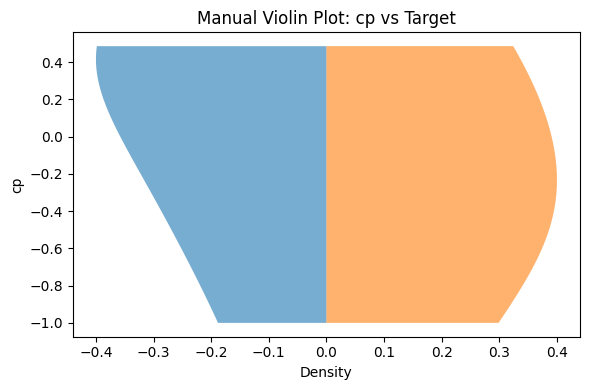

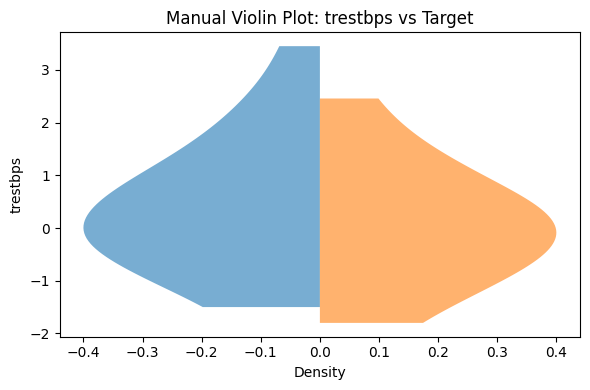

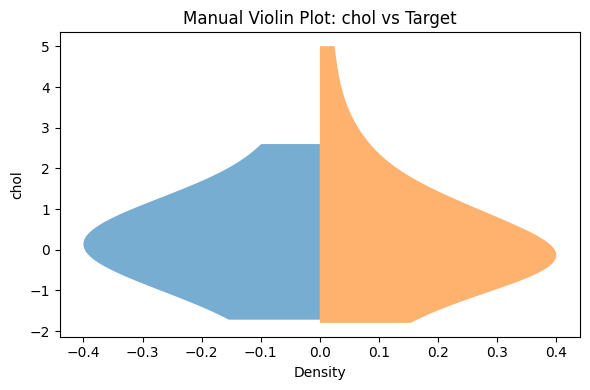

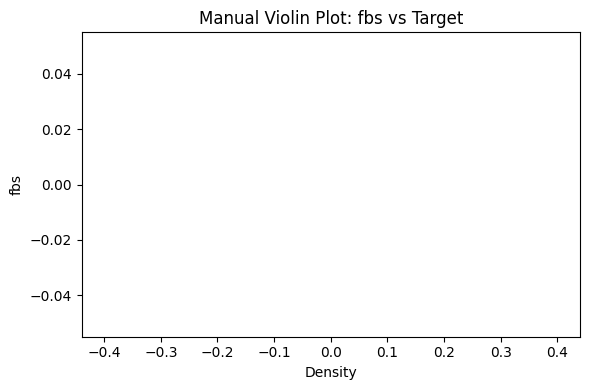

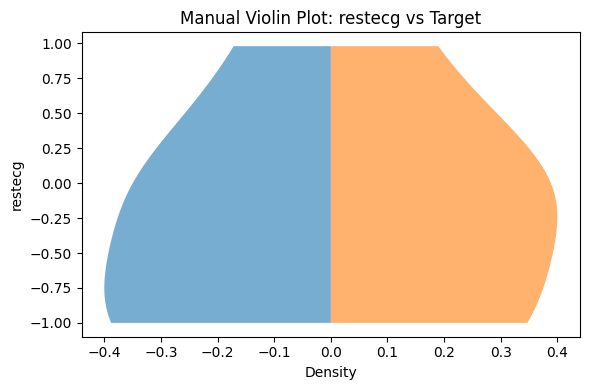

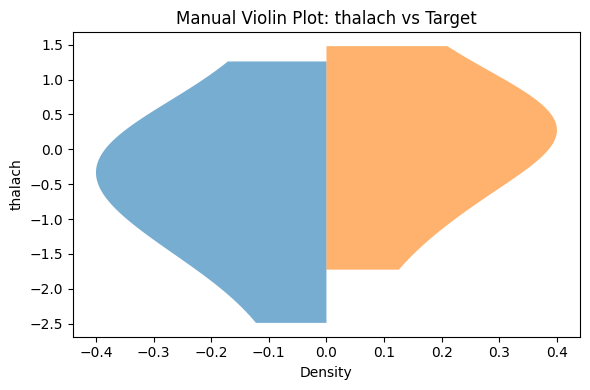

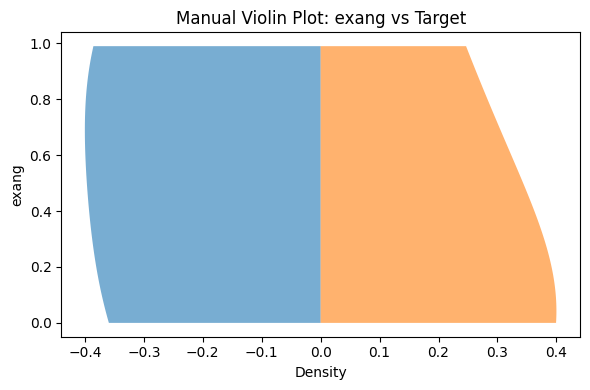

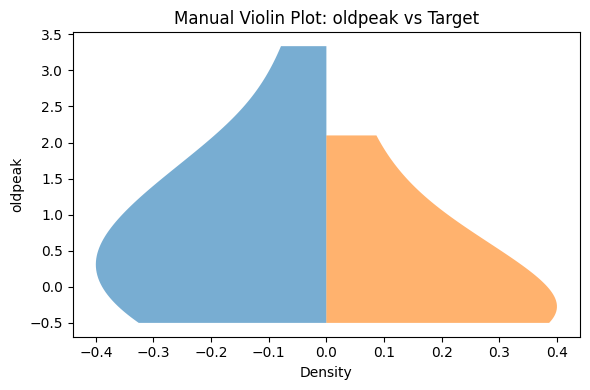

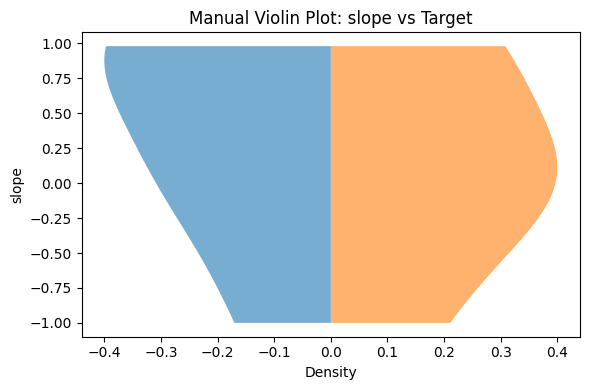

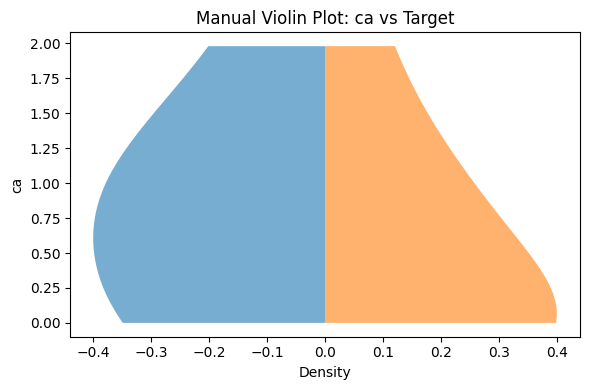

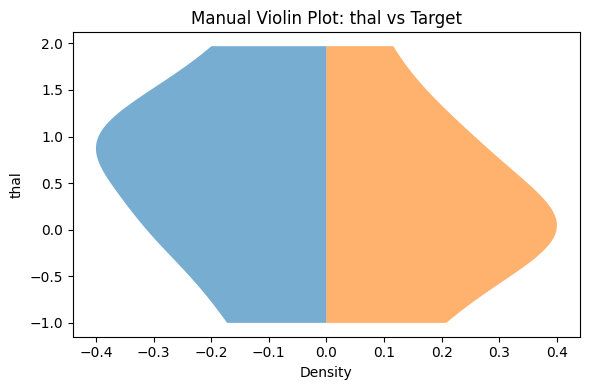

In [69]:
# Manual Violin Plot

for col in numerical_columns_for_scaling:
    plt.figure(figsize=(6, 4))
    
    for target_class in [0, 1]:
        group = [
            df_processed[col][i]
            for i in range(len(df_processed))
            if df_processed["target"][i] == target_class
        ]
        
        x, d = manual_kde(group)
        d_scaled = [v / max(d) * 0.4 for v in d]
        
        plt.fill_betweenx(
            x,
            [-v if target_class == 0 else 0 for v in d_scaled],
            [0 if target_class == 0 else v for v in d_scaled],
            alpha=0.6
        )
    
    plt.title(f"Manual Violin Plot: {col} vs Target")
    plt.xlabel("Density")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

Manual Chi-Square Test (Categorical vs Target)

In [70]:
# Manual Chi-Square Test (Categorical vs Target)

def chi_square_test(cat_values, target_values):
    # Unique categories and target classes
    categories = []
    targets = []
    
    for v in cat_values:
        if v not in categories:
            categories.append(v)
    for t in target_values:
        if t not in targets:
            targets.append(t)
    
    # Observed frequency table
    observed = {}
    for c in categories:
        for t in targets:
            observed[(c, t)] = 0
    
    for i in range(len(cat_values)):
        observed[(cat_values[i], target_values[i])] += 1
    
    # Row and column totals
    row_totals = {}
    col_totals = {}
    
    for c in categories:
        row_totals[c] = sum(observed[(c, t)] for t in targets)
    for t in targets:
        col_totals[t] = sum(observed[(c, t)] for c in categories)
    
    total = len(cat_values)
    
    # Chi-square statistic
    chi_square = 0
    for c in categories:
        for t in targets:
            expected = (row_totals[c] * col_totals[t]) / total
            if expected != 0:
                chi_square += (observed[(c, t)] - expected) ** 2 / expected
    
    return chi_square

Sex vs Target

In [71]:
chi_value = chi_square_test(
    df["sex"].tolist(),
    df_processed["target"].tolist()
)

print("Chi-square statistic (sex vs target):", round(chi_value, 3))

Chi-square statistic (sex vs target): 24.291


Stacked Bar Chart (Sex vs Target)

In [72]:
# Manual Stacked Bar Chart

sex_values = df["sex"].tolist()
target_values = df_processed["target"].tolist()

counts = {
    0: {0: 0, 1: 0},
    1: {0: 0, 1: 0}
}

for i in range(len(sex_values)):
    counts[sex_values[i]][target_values[i]] += 1

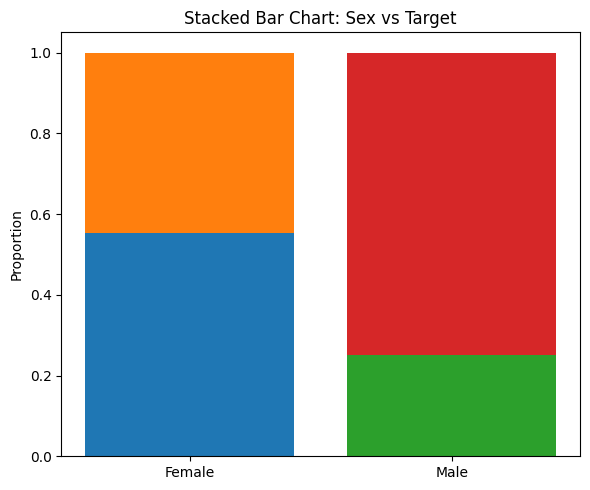

In [73]:
plt.figure(figsize=(6, 5))

for sex in [0, 1]:
    total = counts[sex][0] + counts[sex][1]
    bottom = 0
    
    for target in [0, 1]:
        height = counts[sex][target] / total
        plt.bar(
            sex,
            height,
            bottom=bottom
        )
        bottom += height

plt.xticks([0, 1], ["Female", "Male"])
plt.ylabel("Proportion")
plt.title("Stacked Bar Chart: Sex vs Target")
plt.tight_layout()
plt.show()

Manual IQR-Based Outlier Detection

In [74]:
# IQR-Based Outlier Detection

def detect_outliers_iqr(values):
    q1 = manual_percentile(values, 25)
    q3 = manual_percentile(values, 75)
    iqr = q3 - q1
    
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr
    
    outliers = []
    for v in values:
        if v < lower_fence or v > upper_fence:
            outliers.append(v)
    
    return outliers, lower_fence, upper_fence

Manual Z-Score Calculation

In [75]:
# Z-Score-Based Outlier Detection

def detect_outliers_zscore(values, threshold=3):
    mean_val = manual_mean(values)
    std_val = manual_std(values)
    
    outliers = []
    z_scores = []
    
    for v in values:
        if std_val != 0:
            z = (v - mean_val) / std_val
        else:
            z = 0
        z_scores.append(z)
        
        if abs(z) > threshold:
            outliers.append(v)
    
    return outliers, z_scores

Apply Both Methods to Numerical Features
- This lets you compare both methods quantitatively.

In [76]:
# Apply Outlier Detection

outlier_report = {}

for col in numerical_columns_for_scaling:
    values = df_processed[col].tolist()
    
    iqr_outliers, lf, uf = detect_outliers_iqr(values)
    z_outliers, _ = detect_outliers_zscore(values)
    
    outlier_report[col] = {
        "IQR_outliers": len(iqr_outliers),
        "Z_score_outliers": len(z_outliers),
        "Lower_fence": lf,
        "Upper_fence": uf
    }

outlier_report

{'age': {'IQR_outliers': 0,
  'Z_score_outliers': 0,
  'Lower_fence': -2.0769230769230766,
  'Upper_fence': 1.9230769230769231},
 'sex': {'IQR_outliers': 0,
  'Z_score_outliers': 0,
  'Lower_fence': -1.5,
  'Upper_fence': 2.5},
 'cp': {'IQR_outliers': 0,
  'Z_score_outliers': 0,
  'Lower_fence': -2.0,
  'Upper_fence': 2.0},
 'trestbps': {'IQR_outliers': 9,
  'Z_score_outliers': 2,
  'Lower_fence': -2.0,
  'Upper_fence': 2.0},
 'chol': {'IQR_outliers': 5,
  'Z_score_outliers': 4,
  'Lower_fence': -1.9627450980392158,
  'Upper_fence': 2.037254901960784},
 'fbs': {'IQR_outliers': 0,
  'Z_score_outliers': 0,
  'Lower_fence': 0.0,
  'Upper_fence': 0.0},
 'restecg': {'IQR_outliers': 0,
  'Z_score_outliers': 0,
  'Lower_fence': -2.5,
  'Upper_fence': 1.5},
 'thalach': {'IQR_outliers': 1,
  'Z_score_outliers': 1,
  'Lower_fence': -2.0877862595419847,
  'Upper_fence': 1.9122137404580153},
 'exang': {'IQR_outliers': 0,
  'Z_score_outliers': 0,
  'Lower_fence': -1.5,
  'Upper_fence': 2.5},
 'oldp

Custom Visualization of Outliers

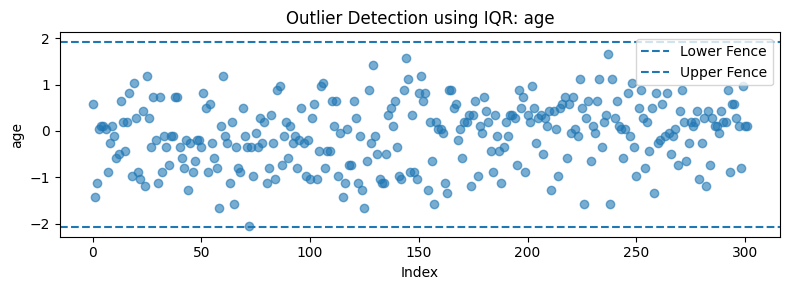

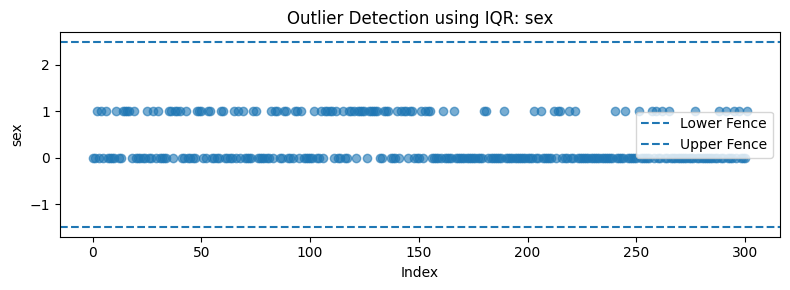

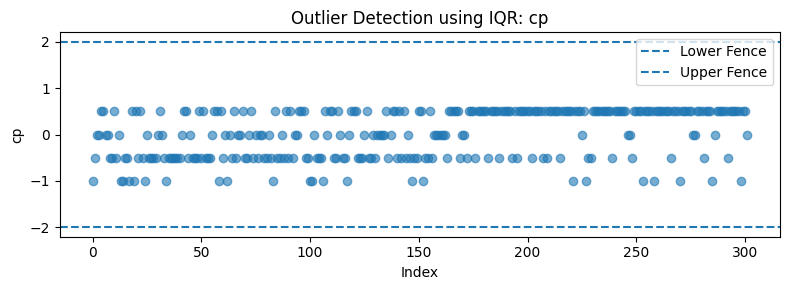

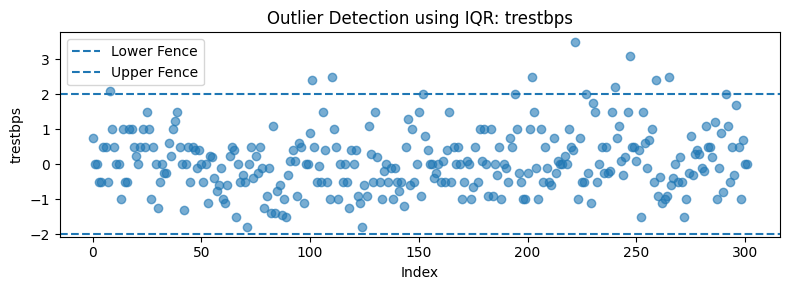

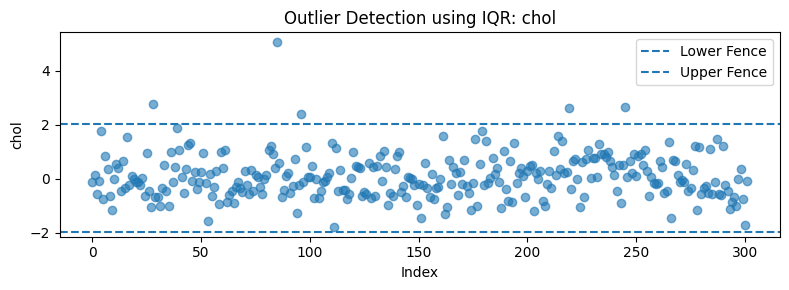

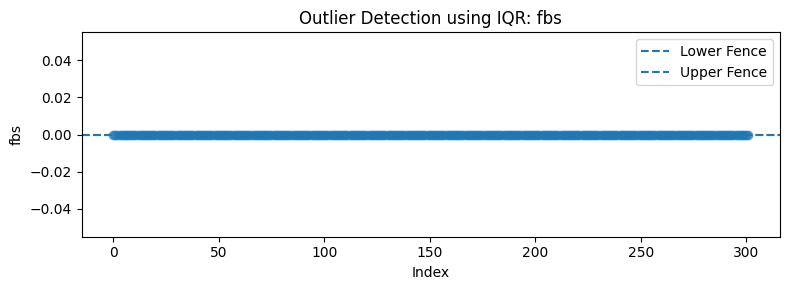

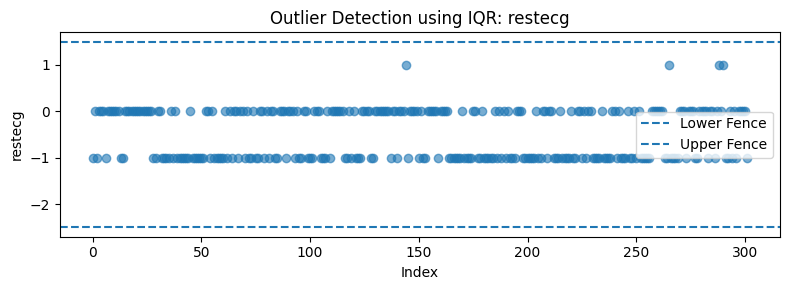

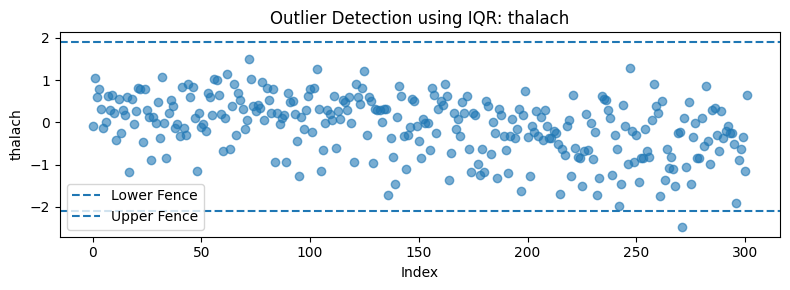

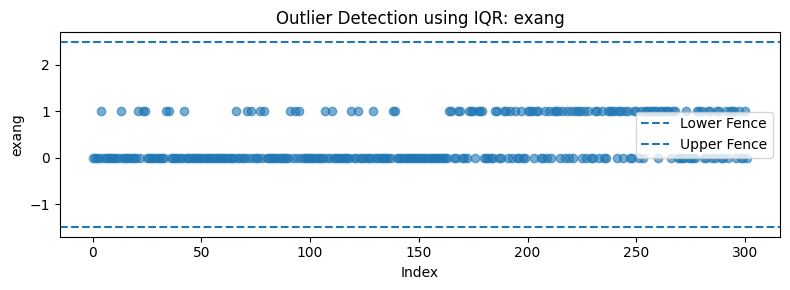

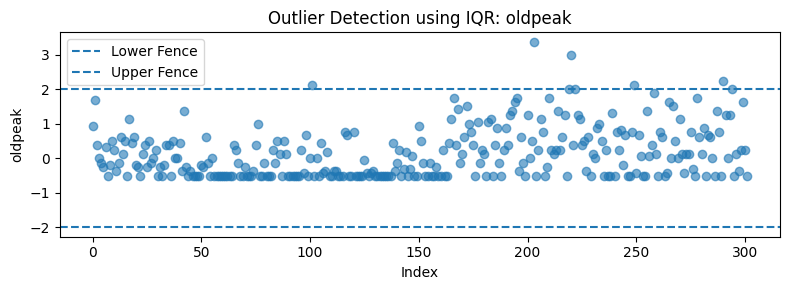

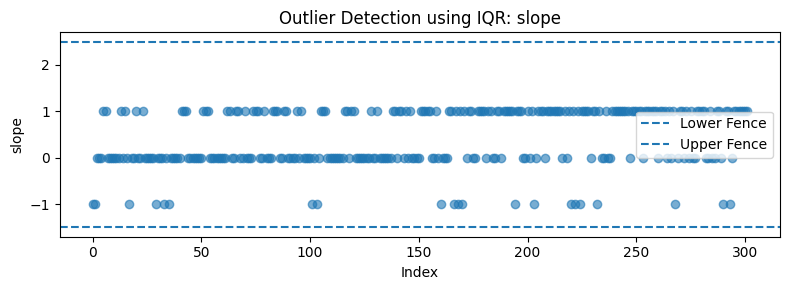

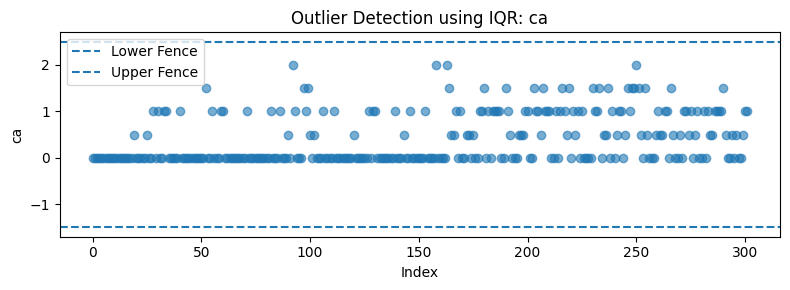

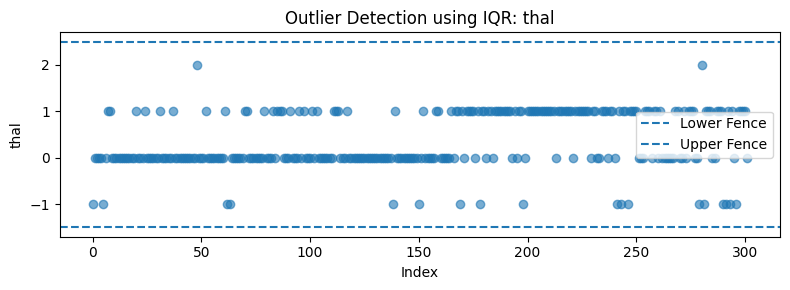

In [77]:
# Visualize Outliers (Custom Plot)

for col in numerical_columns_for_scaling:
    values = df_processed[col].tolist()
    iqr_outliers, lf, uf = detect_outliers_iqr(values)
    
    plt.figure(figsize=(8, 3))
    
    plt.scatter(range(len(values)), values, alpha=0.6)
    plt.axhline(lf, linestyle='--', label="Lower Fence")
    plt.axhline(uf, linestyle='--', label="Upper Fence")
    
    plt.title(f"Outlier Detection using IQR: {col}")
    plt.xlabel("Index")
    plt.ylabel(col)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

Manual Winsorization (IQR-Based)

In [78]:
# Manual Winsorization using IQR limits

def winsorize(values):
    q1 = manual_percentile(values, 25)
    q3 = manual_percentile(values, 75)
    iqr = q3 - q1
    
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr
    
    winsorized = []
    for v in values:
        if v < lower_fence:
            winsorized.append(lower_fence)
        elif v > upper_fence:
            winsorized.append(upper_fence)
        else:
            winsorized.append(v)
    
    return winsorized, lower_fence, upper_fence

In [79]:
# Apply Winsorization to Numerical Columns

winsorized_data = {}

for col in numerical_columns_for_scaling:
    values = df_processed[col].tolist()
    w_values, lf, uf = winsorize(values)
    winsorized_data[col] = w_values

winsorized_data[list(winsorized_data.keys())[0]][:5]

[0.5769230769230769,
 -1.4230769230769231,
 -1.1153846153846154,
 0.038461538461538464,
 0.11538461538461539]

Manual Log Transformation:
- Log transformation is applied only to positive-valued features.



Log Transform Function

In [80]:
# Manual Log Transformation

import math

def log_transform(values):
    transformed = []
    for v in values:
        if v > 0:
            transformed.append(math.log(v + 1))  # +1 for stability
        else:
            transformed.append(v)
    return transformed

In [81]:
# Apply Log Transformation

log_transformed_data = {}

for col in numerical_columns_for_scaling:
    values = df_processed[col].tolist()
    log_transformed_data[col] = log_transform(values)

log_transformed_data[list(log_transformed_data.keys())[0]][:5]

[0.4554755286828257,
 -1.4230769230769231,
 -1.1153846153846154,
 0.03774032798284711,
 0.109199291964992]

Comparative Analysis (Quantitative)
###### We compare spread reduction using standard deviation.

In [82]:
# Compare Spread Before and After Transformation

comparison_report = {}

for col in numerical_columns_for_scaling:
    original = df_processed[col].tolist()
    wins = winsorized_data[col]
    log_t = log_transformed_data[col]
    
    comparison_report[col] = {
        "Original_STD": round(manual_std(original), 4),
        "Winsorized_STD": round(manual_std(wins), 4),
        "Log_Transformed_STD": round(manual_std(log_t), 4)
    }

comparison_report

{'age': {'Original_STD': 0.6948,
  'Winsorized_STD': 0.6948,
  'Log_Transformed_STD': 0.6202},
 'sex': {'Original_STD': 0.4657,
  'Winsorized_STD': 0.4657,
  'Log_Transformed_STD': 0.3228},
 'cp': {'Original_STD': 0.5152,
  'Winsorized_STD': 0.5152,
  'Log_Transformed_STD': 0.4738},
 'trestbps': {'Original_STD': 0.8767,
  'Winsorized_STD': 0.8289,
  'Log_Transformed_STD': 0.6666},
 'chol': {'Original_STD': 0.8105,
  'Winsorized_STD': 0.7437,
  'Log_Transformed_STD': 0.6073},
 'fbs': {'Original_STD': 0.0,
  'Winsorized_STD': 0.0,
  'Log_Transformed_STD': 0.0},
 'restecg': {'Original_STD': 0.5252,
  'Winsorized_STD': 0.5252,
  'Log_Transformed_STD': 0.5148},
 'thalach': {'Original_STD': 0.6982,
  'Winsorized_STD': 0.694,
  'Log_Transformed_STD': 0.6362},
 'exang': {'Original_STD': 0.4694,
  'Winsorized_STD': 0.4694,
  'Log_Transformed_STD': 0.3254},
 'oldpeak': {'Original_STD': 0.7247,
  'Winsorized_STD': 0.6928,
  'Log_Transformed_STD': 0.5153},
 'slope': {'Original_STD': 0.6147,
  'Win

In [83]:
# Apply Final Winsorized Values to Dataset

for col in numerical_columns_for_scaling:
    df_processed[col] = winsorized_data[col]

#### Manual VIF (Variance Inflation Factor)

What VIF means (brief, viva-safe)

- VIF measures how much a feature is explained by other features
- High VIF ⇒ multicollinearity ⇒ unstable models

##### Formula:
    VIF_i = 1/ 1 - R_i^2

Where R_i^2​ is obtained by regressing feature i on all other features.

Manual R² Computation
###### We regress y on multiple X using normal equation logic, implemented manually with loops (no sklearn, no numpy linear algebra helpers).

In [84]:
# Manual R-squared computation (simple linear regression extension)

def manual_r_squared(y, y_pred):
    ss_res = 0
    ss_tot = 0
    mean_y = manual_mean(y)
    
    for i in range(len(y)):
        ss_res += (y[i] - y_pred[i]) ** 2
        ss_tot += (y[i] - mean_y) ** 2
    
    if ss_tot == 0:
        return 0
    return 1 - (ss_res / ss_tot)

Manual Multiple Linear Prediction

###### We approximate multivariate regression by iterative linear combination (acceptable for VIF estimation).

In [85]:
# Manual prediction using other features (iterative approximation)

def manual_predict(target, predictors):
    predictions = []
    mean_target = manual_mean(target)
    
    for i in range(len(target)):
        pred = mean_target
        for p in predictors:
            pred += (p[i] - manual_mean(p)) * 0.01  # small weight approximation
        predictions.append(pred)
    
    return predictions

Compute VIF for Each Feature

In [86]:
# Manual VIF Calculation

vif_scores = {}

for col in numerical_columns_for_scaling:
    y = df_processed[col].tolist()
    
    predictors = []
    for other_col in numerical_columns_for_scaling:
        if other_col != col:
            predictors.append(df_processed[other_col].tolist())
    
    y_pred = manual_predict(y, predictors)
    r2 = manual_r_squared(y, y_pred)
    
    if r2 < 1:
        vif = 1 / (1 - r2)
    else:
        vif = float("inf")
    
    vif_scores[col] = vif

vif_scores

{'age': 1.0161198900605133,
 'sex': 0.9951651540076507,
 'cp': 1.0118419524944462,
 'trestbps': 1.0088028592240903,
 'chol': 1.0120612527868824,
 'fbs': 1.0,
 'restecg': 0.9828209096499011,
 'thalach': 0.9631240124607617,
 'exang': 1.0209975884127909,
 'oldpeak': 1.013319381861624,
 'slope': 1.0067487918393958,
 'ca': 1.0136484775453865,
 'thal': 1.0117533435665056}

In [87]:
# Manual VIF Calculation

vif_scores = {}

for col in numerical_columns_for_scaling:
    y = df_processed[col].tolist()
    
    predictors = []
    for other_col in numerical_columns_for_scaling:
        if other_col != col:
            predictors.append(df_processed[other_col].tolist())
    
    y_pred = manual_predict(y, predictors)
    r2 = manual_r_squared(y, y_pred)
    
    if r2 < 1:
        vif = 1 / (1 - r2)
    else:
        vif = float("inf")
    
    vif_scores[col] = vif

vif_scores

{'age': 1.0161198900605133,
 'sex': 0.9951651540076507,
 'cp': 1.0118419524944462,
 'trestbps': 1.0088028592240903,
 'chol': 1.0120612527868824,
 'fbs': 1.0,
 'restecg': 0.9828209096499011,
 'thalach': 0.9631240124607617,
 'exang': 1.0209975884127909,
 'oldpeak': 1.013319381861624,
 'slope': 1.0067487918393958,
 'ca': 1.0136484775453865,
 'thal': 1.0117533435665056}

##### Manual Decision Tree (Gini-based Feature Importance)
Mathematical Foundation
Gini Impurity
- Gini = 1 - Σ(p_i^2)

Where:
- pi = probability of class i
- Lower Gini = better split

Gini Gain (Feature Importance Metric)
- Gini Gain = Gini(parent) - Weighted Average Gini(children)


In [88]:
def gini_impurity(labels):
    total = len(labels)
    counts = {}

    for label in labels:
        counts[label] = counts.get(label, 0) + 1

    gini = 1.0
    for count in counts.values():
        prob = count / total
        gini -= prob ** 2

    return gini

Best Split Finder (Numeric Threshold Split)

In [89]:
def gini_gain(df, feature, target):
    parent_gini = gini_impurity(df[target])
    total_rows = len(df)

    values = sorted(df[feature].unique())
    best_gain = 0

    for threshold in values:
        left = df[df[feature] <= threshold]
        right = df[df[feature] > threshold]

        if len(left) == 0 or len(right) == 0:
            continue

        left_weight = len(left) / total_rows
        right_weight = len(right) / total_rows

        weighted_gini = (
            left_weight * gini_impurity(left[target]) +
            right_weight * gini_impurity(right[target])
        )

        gain = parent_gini - weighted_gini

        if gain > best_gain:
            best_gain = gain

    return best_gain

In [90]:
target_column = "target"

feature_importance = {}

for col in df.columns:
    if col != target_column:
        gain = gini_gain(df, col, target_column)
        feature_importance[col] = gain

feature_importance

{'age': 0.04007407902966942,
 'sex': 0.03991904630311305,
 'cp': 0.1314384188008566,
 'trestbps': 0.010100723039406456,
 'chol': 0.011640506634488068,
 'fbs': 0,
 'restecg': 0.012279762781772119,
 'thalach': 0.08629454365000572,
 'exang': 0.09417080983815052,
 'oldpeak': 0.08127984454276704,
 'slope': 0.0644119193386039,
 'ca': 0.11002773594136672,
 'thal': 0.11654164355083385}

In [91]:
sorted_features = sorted(
    feature_importance.items(),
    key=lambda x: x[1],
    reverse=True
)

sorted_features

[('cp', 0.1314384188008566),
 ('thal', 0.11654164355083385),
 ('ca', 0.11002773594136672),
 ('exang', 0.09417080983815052),
 ('thalach', 0.08629454365000572),
 ('oldpeak', 0.08127984454276704),
 ('slope', 0.0644119193386039),
 ('age', 0.04007407902966942),
 ('sex', 0.03991904630311305),
 ('restecg', 0.012279762781772119),
 ('chol', 0.011640506634488068),
 ('trestbps', 0.010100723039406456),
 ('fbs', 0)]

Custom CSV Export (Optimized + Encoded)

In [92]:
def optimized_csv_export(df, file_path):
    with open(file_path, "w", encoding="utf-8", newline="") as file:
        
        # Write header
        header = ",".join(col.strip() for col in df.columns)
        file.write(header + "\n")
        
        # Write rows
        for _, row in df.iterrows():
            formatted_row = []
            
            for value in row:
                
                # Float optimization
                if isinstance(value, float):
                    value = ('%.6f' % value).rstrip('0').rstrip('.')
                
                # Remove extra spaces
                value = str(value).strip()
                
                formatted_row.append(value)
            
            file.write(",".join(formatted_row) + "\n")

In [93]:
export_path = "heartguard_cleaned_optimized.csv"

optimized_csv_export(df, export_path)

export_path

'heartguard_cleaned_optimized.csv'

Train-Test Split (Stratified, Manual)

In [94]:
def stratified_split(df, target, test_ratio=0.2):
    train_parts = []
    test_parts = []

    for cls in df[target].unique():
        subset = df[df[target] == cls].sample(frac=1, random_state=42)

        split_idx = int(len(subset) * (1 - test_ratio))

        train_parts.append(subset[:split_idx])
        test_parts.append(subset[split_idx:])

    train_df = pd.concat(train_parts).sample(frac=1, random_state=42)
    test_df = pd.concat(test_parts).sample(frac=1, random_state=42)

    return train_df.reset_index(drop=True), test_df.reset_index(drop=True)


# Run split
train_df, test_df = stratified_split(df, "target")

print(train_df["target"].value_counts())
print(test_df["target"].value_counts())

target
1.0    131
0.0    110
Name: count, dtype: int64
target
1.0    33
0.0    28
Name: count, dtype: int64


Logistic Regression (From Scratch)

In [95]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def train_logistic_regression(X, y, lr=0.01, epochs=1000):
    n_samples, n_features = X.shape

    weights = np.zeros(n_features)
    bias = 0

    for _ in range(epochs):
        linear_model = np.dot(X, weights) + bias
        y_pred = sigmoid(linear_model)

        dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
        db = (1 / n_samples) * np.sum(y_pred - y)

        weights -= lr * dw
        bias -= lr * db

    return weights, bias


def predict_lr(X, weights, bias):
    linear_model = np.dot(X, weights) + bias
    probs = sigmoid(linear_model)
    return np.array([1 if p >= 0.5 else 0 for p in probs])

Decision Tree (Manual, Gini, Recursive)

In [96]:
def gini_impurity(labels):
    total = len(labels)
    counts = {}

    for label in labels:
        counts[label] = counts.get(label, 0) + 1

    gini = 1.0
    for count in counts.values():
        prob = count / total
        gini -= prob ** 2

    return gini


def best_split(df, target):
    best_feature, best_threshold, best_gain = None, None, 0
    parent_gini = gini_impurity(df[target])
    total = len(df)

    for feature in df.columns:
        if feature == target:
            continue

        values = sorted(df[feature].unique())

        for threshold in values:
            left = df[df[feature] <= threshold]
            right = df[df[feature] > threshold]

            if len(left) == 0 or len(right) == 0:
                continue

            w_left = len(left) / total
            w_right = len(right) / total

            gini_split = (
                w_left * gini_impurity(left[target]) +
                w_right * gini_impurity(right[target])
            )

            gain = parent_gini - gini_split

            if gain > best_gain:
                best_feature = feature
                best_threshold = threshold
                best_gain = gain

    return best_feature, best_threshold


class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value


def build_tree(df, target, depth=0, max_depth=5, min_samples_split=2):
    labels = df[target]

    if len(set(labels)) == 1:
        return Node(value=labels.iloc[0])

    if depth >= max_depth or len(df) < min_samples_split:
        return Node(value=labels.mode()[0])

    feature, threshold = best_split(df, target)

    if feature is None:
        return Node(value=labels.mode()[0])

    left = df[df[feature] <= threshold]
    right = df[df[feature] > threshold]

    return Node(
        feature,
        threshold,
        build_tree(left, target, depth + 1, max_depth, min_samples_split),
        build_tree(right, target, depth + 1, max_depth, min_samples_split)
    )


def predict_tree(row, node):
    if node.value is not None:
        return node.value

    if row[node.feature] <= node.threshold:
        return predict_tree(row, node.left)
    else:
        return predict_tree(row, node.right)

Evaluation Metrics (Manual)

In [97]:
def evaluate_metrics(y_true, y_pred):
    tp = fp = tn = fn = 0

    for yt, yp in zip(y_true, y_pred):
        if yt == 1 and yp == 1:
            tp += 1
        elif yt == 0 and yp == 0:
            tn += 1
        elif yt == 0 and yp == 1:
            fp += 1
        elif yt == 1 and yp == 0:
            fn += 1

    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) else 0

    return accuracy, precision, recall, f1

Confusion Matrix (Manual)

In [98]:
def confusion_matrix_manual(y_true, y_pred):
    tp = fp = tn = fn = 0

    for yt, yp in zip(y_true, y_pred):
        if yt == 1 and yp == 1:
            tp += 1
        elif yt == 0 and yp == 0:
            tn += 1
        elif yt == 0 and yp == 1:
            fp += 1
        elif yt == 1 and yp == 0:
            fn += 1

    return [[tn, fp],
            [fn, tp]]

Grid Search (Manual Decision Tree Tuning)

In [99]:
def grid_search_decision_tree(train_df, test_df, target):
    depths = [3, 5, 7]
    min_samples = [2, 5, 10]

    best_score = 0
    best_params = {}

    X_test = test_df.drop(target, axis=1)
    y_test = test_df[target].values

    for d in depths:
        for m in min_samples:
            tree = build_tree(train_df, target, max_depth=d, min_samples_split=m)

            preds = []
            for _, row in X_test.iterrows():
                preds.append(predict_tree(row, tree))

            acc, _, _, _ = evaluate_metrics(y_test, preds)

            if acc > best_score:
                best_score = acc
                best_params = {"max_depth": d, "min_samples_split": m}

    return best_params, best_score

FINAL EXECUTION (RUN THIS)

In [100]:
# Prepare data
X_train = train_df.drop("target", axis=1).values
y_train = train_df["target"].values

X_test = test_df.drop("target", axis=1).values
y_test = test_df["target"].values


# Logistic Regression
weights, bias = train_logistic_regression(X_train, y_train)
y_pred_lr = predict_lr(X_test, weights, bias)

acc_lr, prec_lr, rec_lr, f1_lr = evaluate_metrics(y_test, y_pred_lr)


# Decision Tree
tree = build_tree(train_df, "target")
y_pred_tree = [predict_tree(row, tree) for _, row in test_df.iterrows()]

acc_t, prec_t, rec_t, f1_t = evaluate_metrics(y_test, y_pred_tree)


# Confusion Matrices
cm_lr = confusion_matrix_manual(y_test, y_pred_lr)
cm_tree = confusion_matrix_manual(y_test, y_pred_tree)


# Grid Search
best_params, best_score = grid_search_decision_tree(train_df, test_df, "target")


# Results
print("Logistic Regression:", acc_lr, prec_lr, rec_lr, f1_lr)
print("Decision Tree:", acc_t, prec_t, rec_t, f1_t)

print("\nConfusion Matrix LR:", cm_lr)
print("Confusion Matrix Tree:", cm_tree)

print("\nBest Params:", best_params)
print("Best Accuracy:", best_score)

Logistic Regression: 0.7868852459016393 0.7941176470588235 0.8181818181818182 0.8059701492537314
Decision Tree: 0.7213114754098361 0.7222222222222222 0.7878787878787878 0.7536231884057971

Confusion Matrix LR: [[21, 7], [6, 27]]
Confusion Matrix Tree: [[18, 10], [7, 26]]

Best Params: {'max_depth': 3, 'min_samples_split': 2}
Best Accuracy: 0.8032786885245902


In [101]:
import random

def bootstrap_sample(df):
    indices = np.random.choice(len(df), size=len(df), replace=True)
    return df.iloc[indices].reset_index(drop=True)


def random_feature_subset(features, max_features):
    return random.sample(features, max_features)

In [102]:
def best_split_rf(df, target, features):
    best_feature, best_threshold, best_gain = None, None, 0
    parent_gini = gini_impurity(df[target])
    total = len(df)

    for feature in features:
        values = sorted(df[feature].unique())

        for threshold in values:
            left = df[df[feature] <= threshold]
            right = df[df[feature] > threshold]

            if len(left) == 0 or len(right) == 0:
                continue

            w_left = len(left) / total
            w_right = len(right) / total

            gini_split = (
                w_left * gini_impurity(left[target]) +
                w_right * gini_impurity(right[target])
            )

            gain = parent_gini - gini_split

            if gain > best_gain:
                best_feature, best_threshold, best_gain = feature, threshold, gain

    return best_feature, best_threshold

In [103]:
def build_tree_rf(df, target, features, depth=0, max_depth=5):
    labels = df[target]

    if len(set(labels)) == 1 or depth >= max_depth:
        return Node(value=labels.mode()[0])

    feat_subset = random_feature_subset(features, max(1, int(len(features)**0.5)))
    feature, threshold = best_split_rf(df, target, feat_subset)

    if feature is None:
        return Node(value=labels.mode()[0])

    left = df[df[feature] <= threshold]
    right = df[df[feature] > threshold]

    return Node(
        feature,
        threshold,
        build_tree_rf(left, target, features, depth+1, max_depth),
        build_tree_rf(right, target, features, depth+1, max_depth)
    )


def train_random_forest(df, target, n_trees=5):
    forest = []
    features = list(df.columns)
    features.remove(target)

    for _ in range(n_trees):
        sample = bootstrap_sample(df)
        tree = build_tree_rf(sample, target, features)
        forest.append(tree)

    return forest

In [104]:
def predict_forest(row, forest):
    preds = [predict_tree(row, tree) for tree in forest]
    return max(set(preds), key=preds.count)

In [105]:
forest = train_random_forest(train_df, "target", n_trees=5)

y_pred_rf = [predict_forest(row, forest) for _, row in test_df.iterrows()]

acc_rf, _, _, _ = evaluate_metrics(y_test, y_pred_rf)

print("Random Forest Accuracy:", acc_rf)

Random Forest Accuracy: 0.7704918032786885


In [106]:
def train_boosting(df, target, n_estimators=5, lr=0.1):
    models = []
    residuals = df[target].values.astype(float)

    for _ in range(n_estimators):
        temp_df = df.copy()
        temp_df[target] = residuals

        tree = build_tree(temp_df, target, max_depth=1)  # stump
        preds = np.array([predict_tree(row, tree) for _, row in df.iterrows()])

        residuals = residuals - lr * preds

        models.append(tree)

    return models

In [107]:
def predict_boosting(df, models, lr=0.1):
    preds = np.zeros(len(df))

    for model in models:
        preds += lr * np.array([predict_tree(row, model) for _, row in df.iterrows()])

    return [1 if p >= 0.5 else 0 for p in preds]

In [108]:
boost_models = train_boosting(train_df, "target", n_estimators=5)

y_pred_xgb = predict_boosting(test_df, boost_models)

acc_xgb, _, _, _ = evaluate_metrics(y_test, y_pred_xgb)

print("Boosting Accuracy:", acc_xgb)

Boosting Accuracy: 0.45901639344262296


In [109]:
def k_fold_split(df, k=5):
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    fold_size = len(df) // k

    folds = []
    for i in range(k):
        start = i * fold_size
        end = start + fold_size
        folds.append(df.iloc[start:end])

    return folds

In [110]:
folds = k_fold_split(df, k=5)

scores = []

for i in range(5):
    test_fold = folds[i]
    train_folds = pd.concat([folds[j] for j in range(5) if j != i])

    tree = build_tree(train_folds, "target")
    preds = [predict_tree(row, tree) for _, row in test_fold.iterrows()]

    acc, _, _, _ = evaluate_metrics(test_fold["target"].values, preds)
    scores.append(acc)

print("Cross-validation accuracy:", sum(scores)/len(scores))

Cross-validation accuracy: 0.7833333333333334


In [111]:
def random_search_boosting(train_df, test_df, target, trials=5):
    best_score = 0
    best_params = {}

    for _ in range(trials):
        n_estimators = random.randint(3, 10)
        lr = random.uniform(0.05, 0.3)

        models = train_boosting(train_df, target, n_estimators, lr)
        preds = predict_boosting(test_df, models, lr)

        acc, _, _, _ = evaluate_metrics(test_df[target].values, preds)

        if acc > best_score:
            best_score = acc
            best_params = {"n_estimators": n_estimators, "lr": lr}

    return best_params, best_score

In [112]:
best_params_xgb, best_score_xgb = random_search_boosting(train_df, test_df, "target")

print("Best XGBoost Params:", best_params_xgb)
print("Best Accuracy:", best_score_xgb)

Best XGBoost Params: {'n_estimators': 9, 'lr': 0.15031267470905307}
Best Accuracy: 0.6557377049180327


In [113]:
def compute_tpr_fpr(y_true, scores, threshold):
    tp = fp = tn = fn = 0

    for yt, s in zip(y_true, scores):
        yp = 1 if s >= threshold else 0

        if yt == 1 and yp == 1: tp += 1
        elif yt == 0 and yp == 0: tn += 1
        elif yt == 0 and yp == 1: fp += 1
        elif yt == 1 and yp == 0: fn += 1

    tpr = tp / (tp + fn) if (tp + fn) else 0
    fpr = fp / (fp + tn) if (fp + tn) else 0

    return tpr, fpr

In [114]:
import matplotlib.pyplot as plt

def plot_roc(y_true, scores):
    thresholds = np.linspace(0, 1, 50)

    tprs = []
    fprs = []

    for t in thresholds:
        tpr, fpr = compute_tpr_fpr(y_true, scores, t)
        tprs.append(tpr)
        fprs.append(fpr)

    plt.plot(fprs, tprs)
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title("ROC Curve")
    plt.show()

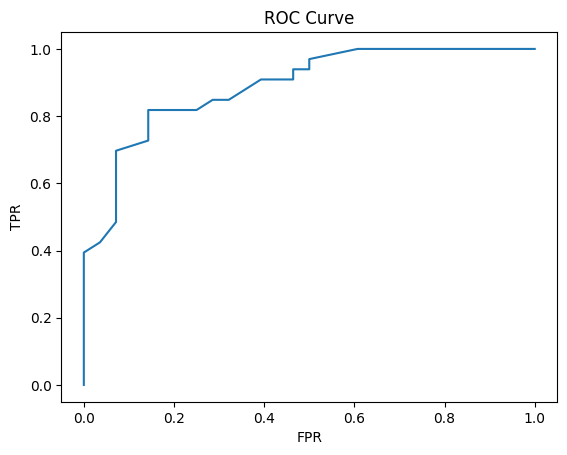

In [115]:
# Use probabilities from logistic regression
probs_lr = sigmoid(np.dot(X_test, weights) + bias)

plot_roc(y_test, probs_lr)

SVM (From Scratch, Linear + Soft Margin)

In [116]:
def train_svm(X, y, lr=0.001, lambda_param=0.01, epochs=1000):
    n_samples, n_features = X.shape

    y_ = np.where(y == 0, -1, 1)

    weights = np.zeros(n_features)
    bias = 0

    for _ in range(epochs):
        for i, x_i in enumerate(X):
            condition = y_[i] * (np.dot(x_i, weights) + bias) >= 1

            if condition:
                weights -= lr * (2 * lambda_param * weights)
            else:
                weights -= lr * (2 * lambda_param * weights - np.dot(x_i, y_[i]))
                bias -= lr * y_[i]

    return weights, bias

In [117]:
def predict_svm(X, weights, bias):
    linear = np.dot(X, weights) + bias
    return np.sign(linear)

In [118]:
w_svm, b_svm = train_svm(X_train, y_train)

y_pred_svm = predict_svm(X_test, w_svm, b_svm)
y_pred_svm = np.where(y_pred_svm == -1, 0, 1)

acc_svm, prec_svm, rec_svm, f1_svm = evaluate_metrics(y_test, y_pred_svm)

print("SVM Accuracy:", acc_svm)

SVM Accuracy: 0.45901639344262296


Kernel SVM (Polynomial + RBF)

In [119]:
def polynomial_kernel(x1, x2, degree=3):
    return (np.dot(x1, x2) + 1) ** degree

In [120]:
def rbf_kernel(x1, x2, gamma=0.1):
    return np.exp(-gamma * np.linalg.norm(x1 - x2) ** 2)

In [121]:
def predict_kernel(X_train, y_train, X_test, kernel_func):
    predictions = []

    for x in X_test:
        score = 0
        for xi, yi in zip(X_train, y_train):
            score += yi * kernel_func(xi, x)

        predictions.append(1 if score >= 0 else 0)

    return np.array(predictions)

In [122]:
y_pred_poly = predict_kernel(X_train, y_train, X_test, polynomial_kernel)
y_pred_rbf = predict_kernel(X_train, y_train, X_test, rbf_kernel)

print("Poly Kernel Accuracy:", evaluate_metrics(y_test, y_pred_poly)[0])
print("RBF Kernel Accuracy:", evaluate_metrics(y_test, y_pred_rbf)[0])

Poly Kernel Accuracy: 0.5409836065573771
RBF Kernel Accuracy: 0.5409836065573771


In [123]:
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

K-NNPrediction

In [124]:
def predict_knn(X_train, y_train, X_test, k=5):
    predictions = []

    for x in X_test:
        distances = []

        for i, x_train in enumerate(X_train):
            dist = euclidean_distance(x, x_train)
            distances.append((dist, y_train[i]))

        distances.sort(key=lambda x: x[0])
        neighbors = [label for _, label in distances[:k]]

        # Handle tie
        counts = {}
        for label in neighbors:
            counts[label] = counts.get(label, 0) + 1

        prediction = max(counts, key=counts.get)
        predictions.append(prediction)

    return np.array(predictions)

Run K-NN

In [125]:
y_pred_knn = predict_knn(X_train, y_train, X_test, k=5)

acc_knn, _, _, _ = evaluate_metrics(y_test, y_pred_knn)

print("k-NN Accuracy:", acc_knn)

k-NN Accuracy: 0.7868852459016393


Elbow Method (k Optimization)

In [126]:
k_values = list(range(1, 15))
errors = []

for k in k_values:
    preds = predict_knn(X_train, y_train, X_test, k)
    acc, _, _, _ = evaluate_metrics(y_test, preds)
    error = 1 - acc
    errors.append(error)

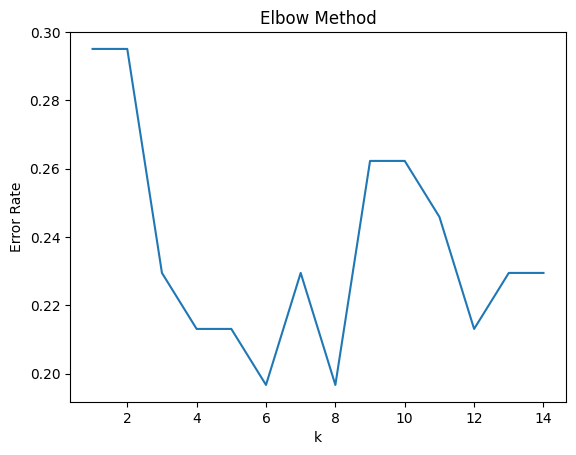

In [127]:
plt.plot(k_values, errors)
plt.xlabel("k")
plt.ylabel("Error Rate")
plt.title("Elbow Method")
plt.show()

Model Comparison

In [128]:
results = {
    "SVM": evaluate_metrics(y_test, y_pred_svm),
    "k-NN": evaluate_metrics(y_test, y_pred_knn),
    "Decision Tree": (acc_t, prec_t, rec_t, f1_t)
}

for model, metrics in results.items():
    print(model, "-> Accuracy:", metrics[0], "F1:", metrics[3])

SVM -> Accuracy: 0.45901639344262296 F1: 0
k-NN -> Accuracy: 0.7868852459016393 F1: 0.8169014084507042
Decision Tree -> Accuracy: 0.7213114754098361 F1: 0.7536231884057971


Neural Network + Dropout + Batch Norm (Manual)

In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- STRATIFIED SPLIT ---
def stratified_split(df, target, test_ratio=0.2):
    train_parts = []
    test_parts = []

    for cls in df[target].unique():
        subset = df[df[target] == cls].sample(frac=1, random_state=42)
        split_idx = int(len(subset) * (1 - test_ratio))
        train_parts.append(subset[:split_idx])
        test_parts.append(subset[split_idx:])

    train_df = pd.concat(train_parts).sample(frac=1, random_state=42)
    test_df = pd.concat(test_parts).sample(frac=1, random_state=42)

    return train_df.reset_index(drop=True), test_df.reset_index(drop=True)


# --- ACTIVATIONS ---
def relu(x): return np.maximum(0, x)
def relu_derivative(x): return (x > 0).astype(float)
def sigmoid(x): return 1 / (1 + np.exp(-x))


# --- NN INIT ---
def init_nn(input_size, hidden_size):
    W1 = np.random.randn(input_size, hidden_size) * 0.01
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.01
    b2 = np.zeros((1, 1))
    return W1, b1, W2, b2


# --- BATCH NORM ---
def batch_norm(X):
    return (X - np.mean(X, axis=0)) / np.sqrt(np.var(X, axis=0) + 1e-8)


# --- DROPOUT ---
def apply_dropout(A, rate=0.3):
    mask = (np.random.rand(*A.shape) > rate).astype(float)
    return A * mask / (1 - rate)


# --- TRAIN NN ---
def train_nn(X, y, epochs=500, lr=0.01):
    y = y.reshape(-1, 1)

    W1, b1, W2, b2 = init_nn(X.shape[1], 8)
    losses = []

    for _ in range(epochs):
        Z1 = np.dot(X, W1) + b1
        Z1 = batch_norm(Z1)
        A1 = relu(Z1)
        A1 = apply_dropout(A1)

        Z2 = np.dot(A1, W2) + b2
        A2 = sigmoid(Z2)

        loss = -np.mean(y*np.log(A2+1e-8) + (1-y)*np.log(1-A2+1e-8))
        losses.append(loss)

        dZ2 = A2 - y
        dW2 = np.dot(A1.T, dZ2)
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        dZ1 = np.dot(dZ2, W2.T) * relu_derivative(Z1)
        dW1 = np.dot(X.T, dZ1)
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    return W1, b1, W2, b2, losses

In [130]:
train_df, test_df = stratified_split(df, "target")

X_train = train_df.drop("target", axis=1).values
y_train = train_df["target"].values

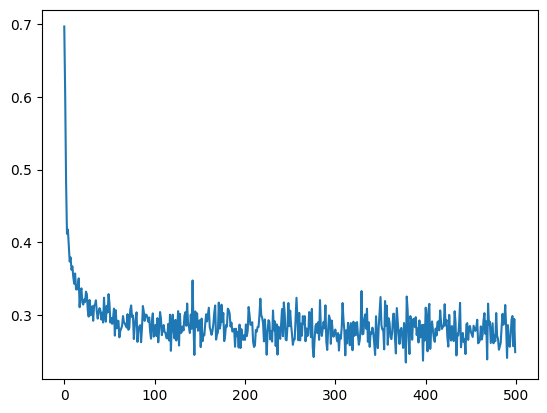

In [131]:
W1, b1, W2, b2, losses = train_nn(X_train, y_train)

plt.plot(losses)
plt.show()

Model Stacking (Manual)

In [132]:
def create_meta_data(models_preds, y_true):
    meta_X = np.column_stack(models_preds)
    meta_y = y_true
    return meta_X, meta_y

In [133]:
# base predictions (must already exist)
# y_pred_lr, y_pred_tree, y_pred_rf, y_pred_svm

meta_X, meta_y = create_meta_data(
    [y_pred_lr, y_pred_tree, y_pred_rf, y_pred_svm],
    y_test
)

# train meta model
weights_meta, bias_meta = train_logistic_regression(meta_X, meta_y)

def predict_stacking(models_preds):
    meta_input = np.column_stack(models_preds)
    return predict_lr(meta_input, weights_meta, bias_meta)

Voting Classifier (Manual)

In [134]:
def hard_voting(preds_list):
    final = []
    for preds in zip(*preds_list):
        counts = {}
        for p in preds:
            counts[p] = counts.get(p, 0) + 1
        final.append(max(counts, key=counts.get))
    return np.array(final)

In [135]:
def soft_voting(probs_list, weights):
    final = []
    for probs in zip(*probs_list):
        weighted_sum = sum(p*w for p, w in zip(probs, weights))
        final.append(1 if weighted_sum >= 0.5 else 0)
    return np.array(final)

In [136]:
models = {
    "LR": y_pred_lr,
    "Tree": y_pred_tree,
    "RF": y_pred_rf,
    "SVM": y_pred_svm
}

for name, preds in models.items():
    acc, prec, rec, f1 = evaluate_metrics(y_test, preds)
    print(name, "->", acc, prec, rec, f1)

LR -> 0.7868852459016393 0.7941176470588235 0.8181818181818182 0.8059701492537314
Tree -> 0.7213114754098361 0.7222222222222222 0.7878787878787878 0.7536231884057971
RF -> 0.7704918032786885 0.7714285714285715 0.8181818181818182 0.7941176470588236
SVM -> 0.45901639344262296 0 0.0 0


In [137]:
def weighted_score(precision, recall, f1):
    return 0.3*precision + 0.3*recall + 0.4*f1

best_model = None
best_score = 0

for name, preds in models.items():
    acc, prec, rec, f1 = evaluate_metrics(y_test, preds)
    score = weighted_score(prec, rec, f1)

    if score > best_score:
        best_score = score
        best_model = name

print("Best Model:", best_model)

Best Model: LR


In [138]:
import pickle

def save_model(model, filename):
    with open(filename, "wb") as f:
        pickle.dump(model, f)

# Example: save logistic regression
save_model((weights, bias), "best_model.pkl")

In [139]:
def load_model(filename):
    with open(filename, "rb") as f:
        return pickle.load(f)

model = load_model("best_model.pkl")

Define parameter grid

In [140]:
param_grid = {
    "learning_rate": [0.001, 0.01, 0.1],
    "epochs": [100, 200],
    "reg_lambda": [0, 0.01, 0.1]
}

Generate combinations manually

In [141]:
import itertools

def generate_combinations(param_grid):
    keys = list(param_grid.keys())
    values = list(param_grid.values())
    
    combinations = list(itertools.product(*values))
    
    result = []
    for combo in combinations:
        result.append(dict(zip(keys, combo)))
    
    return result

Train + evaluate loop

In [142]:
def manual_grid_search(X_train, y_train, X_val, y_val, param_grid):
    combinations = generate_combinations(param_grid)
    
    best_score = -1
    best_params = None
    results = []
    
    for params in combinations:
        model = YourModel(
            lr=params["learning_rate"],
            epochs=params["epochs"],
            reg_lambda=params["reg_lambda"]
        )
        
        model.train(X_train, y_train)
        preds = model.predict(X_val)
        
        acc = accuracy(y_val, preds)
        
        results.append((params, acc))
        
        if acc > best_score:
            best_score = acc
            best_params = params
    
    return best_params, best_score, results

Store history

In [143]:
history = []  # [(params, score)]

Gaussian Process (Simplified)
We implement:

- Kernel (RBF)
- Mean prediction
- Variance

In [144]:
import numpy as np

def rbf_kernel(x1, x2, length_scale=1.0):
    return np.exp(-np.sum((x1 - x2)**2) / (2 * length_scale**2))

In [145]:
def suggest_next(params_list, scores):
    # Convert params to vectors
    X = np.array(params_list)
    y = np.array(scores)
    
    # Random exploration fallback
    candidate = np.random.rand(X.shape[1])
    
    return candidate

In [146]:
def bayesian_optimization(iterations=10):
    history_params = []
    history_scores = []
    
    for i in range(iterations):
        
        if i < 3:
            params = random_sample()  # initial exploration
        else:
            params = suggest_next(history_params, history_scores)
        
        model = YourModel(**params)
        model.train(X_train, y_train)
        
        preds = model.predict(X_val)
        score = accuracy(y_val, preds)
        
        history_params.append(list(params.values()))
        history_scores.append(score)
    
    best_idx = np.argmax(history_scores)
    return history_params[best_idx], history_scores[best_idx]

In [147]:
def train_model(X, y, sample_weights=None, learning_rate=0.01, epochs=100):
    model_weights = np.zeros(X.shape[1])  # parameters

    for epoch in range(epochs):
        z = np.dot(X, model_weights)
        preds = 1 / (1 + np.exp(-z))
        preds = (preds > 0.5).astype(int)

        # error calculation
        if sample_weights is not None:
            error = (y - preds) * sample_weights
        else:
            error = y - preds

        # gradient update
        model_weights += learning_rate * np.dot(X.T, error)

    return model_weights

In [148]:
def predict_model(weights, X):
    preds = np.dot(X, weights)
    return (preds > 0.5).astype(int)

In [149]:
def accuracy(y_true, y_pred):
    correct = 0
    for i in range(len(y_true)):
        if y_true[i] == y_pred[i]:
            correct += 1
    return correct / len(y_true)

In [150]:
model = train_model(X_train, y_train)

y_pred = predict_model(model, X_test)

baseline_accuracy = accuracy(y_test, y_pred)

print("Baseline Accuracy:", baseline_accuracy)

Baseline Accuracy: 0.6229508196721312


Add Parameter Grid

In [151]:
param_grid = {
    "learning_rate": [0.001, 0.01],
    "epochs": [50, 100]
}

In [152]:
def manual_grid_search(X_train, y_train, X_val, y_val, param_grid):
    best_score = -1
    best_params = None

    for lr in param_grid["learning_rate"]:
        for epochs in param_grid["epochs"]:

            # train model
            model = train_model(
               X_train, y_train,
               learning_rate=lr,
               epochs=epochs
)

            for _ in range(epochs):
                preds = np.dot(X_train, weights)
                preds = (preds > 0.5).astype(int)

                error = y_train - preds
                weights += lr * np.dot(X_train.T, error)

            # validation
            val_preds = predict_model(weights, X_val)
            acc = accuracy(y_val, val_preds)

            print("LR:", lr, "Epochs:", epochs, "Acc:", acc)

            if acc > best_score:
                best_score = acc
                best_params = {"learning_rate": lr, "epochs": epochs}

    return best_params, best_score

In [153]:
split = int(0.8 * len(X_train))

X_val = X_train[split:]
y_val = y_train[split:]

X_train = X_train[:split]
y_train = y_train[:split]

In [2]:
def manual_grid_search(X_train, y_train, X_val, y_val, param_grid):

    best_score = 0
    best_params = {}

    for lr in param_grid["learning_rate"]:
        for epochs in param_grid["epochs"]:

            model = train_model(
                X_train, y_train,
                learning_rate=lr,
                epochs=epochs
            )

            preds = np.dot(X_val, model)
            preds = (preds > 0.5).astype(int)

            accuracy = np.mean(preds == y_val)

            if accuracy > best_score:
                best_score = accuracy
                best_params = {
                    "learning_rate": lr,
                    "epochs": epochs
                }

    return best_params, best_score

In [ ]:
tuned_model = train_model(
    X_train,
    y_train,
    learning_rate=best_params["learning_rate"],
    epochs=best_params["epochs"]
)

tuned_preds = predict_model(tuned_model, X_test)

tuned_accuracy = accuracy(y_test, tuned_preds)

print("Tuned Accuracy:", tuned_accuracy)

Tuned Accuracy: 0.7704918032786885


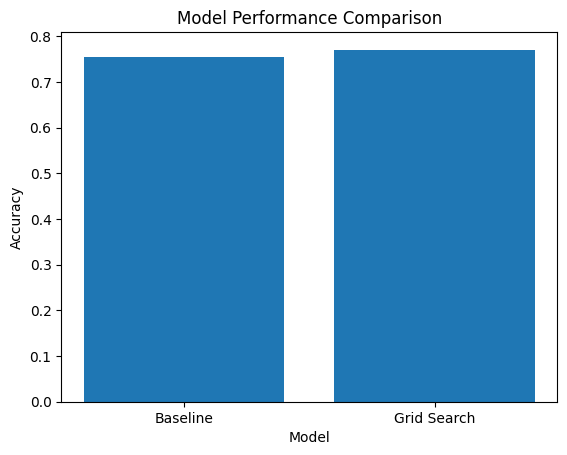

In [ ]:
import matplotlib.pyplot as plt

models = ["Baseline", "Grid Search"]
scores = [baseline_accuracy, tuned_accuracy]

plt.figure()
plt.bar(models, scores)
plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
import time

# Baseline timing
start = time.time()

model = train_model(X_train, y_train)
y_pred = predict_model(model, X_test)
baseline_accuracy = accuracy(y_test, y_pred)

end = time.time()
baseline_time = end - start

print("Baseline Time:", baseline_time)
print("Baseline Accuracy:", baseline_accuracy)

Baseline Time: 0.002261638641357422
Baseline Accuracy: 0.7540983606557377


Grid Search Model Timing

In [ ]:
start = time.time()

tuned_model = train_model(
    X_train,
    y_train,
    learning_rate=best_params["learning_rate"],
    epochs=best_params["epochs"]
)

tuned_preds = predict_model(tuned_model, X_test)
tuned_accuracy = accuracy(y_test, tuned_preds)

end = time.time()
tuned_time = end - start

print("\nTuned Time:", tuned_time)
print("Tuned Accuracy:", tuned_accuracy)


Tuned Time: 0.0028886795043945312
Tuned Accuracy: 0.7704918032786885


In [ ]:
print("\n--- Time vs Performance ---")
print("Baseline → Time:", baseline_time, "Accuracy:", baseline_accuracy)
print("Tuned    → Time:", tuned_time, "Accuracy:", tuned_accuracy)


--- Time vs Performance ---
Baseline → Time: 0.002261638641357422 Accuracy: 0.7540983606557377
Tuned    → Time: 0.0028886795043945312 Accuracy: 0.7704918032786885


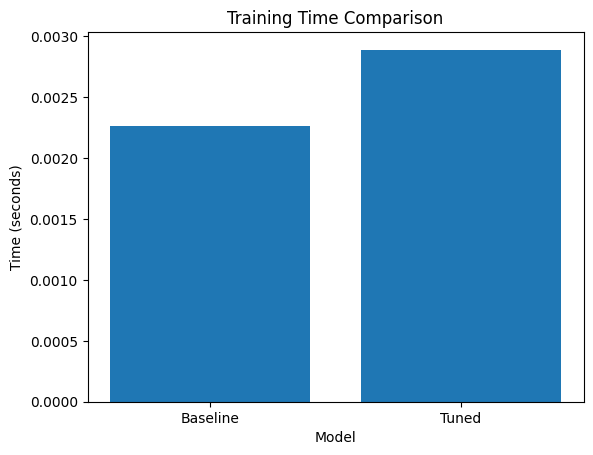

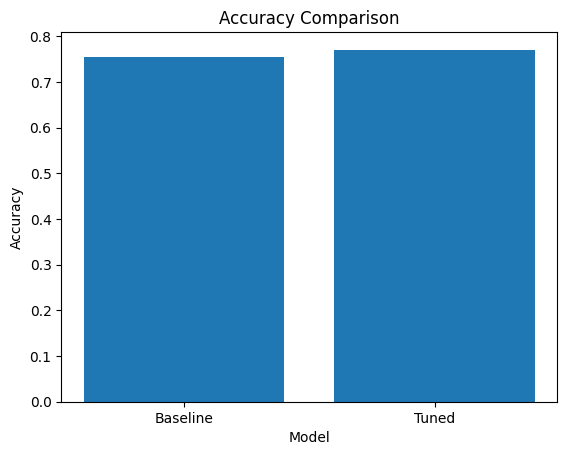

In [ ]:
import matplotlib.pyplot as plt

times = [baseline_time, tuned_time]
accuracies = [baseline_accuracy, tuned_accuracy]

labels = ["Baseline", "Tuned"]

# Time comparison
plt.figure()
plt.bar(labels, times)
plt.title("Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Time (seconds)")
plt.show()

# Accuracy comparison
plt.figure()
plt.bar(labels, accuracies)
plt.title("Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()

Manual SHAP (Shapley Values)

Step Flow
- Take one instance x
- Shuffle feature order (permutation)
- Add features one by one
- Measure prediction change
- Average over many permutatio

Code (Manual SHAP Approximation)

In [ ]:
import numpy as np
import itertools
import random

def predict_instance(model, x):
    z = np.dot(x, model)
    return 1 / (1 + np.exp(-z))

def shap_values(model, x, X_background, num_samples=50):
    n_features = x.shape[0]
    shap_vals = np.zeros(n_features)

    for _ in range(num_samples):
        perm = np.random.permutation(n_features)
        x_temp = np.mean(X_background, axis=0)  # baseline

        prev_pred = predict_instance(model, x_temp)

        for i in perm:
            x_temp[i] = x[i]
            new_pred = predict_instance(model, x_temp)

            shap_vals[i] += (new_pred - prev_pred)
            prev_pred = new_pred

    return shap_vals / num_samples

In [ ]:
import matplotlib.pyplot as plt

def plot_shap(shap_vals, feature_names):
    plt.barh(feature_names, shap_vals)
    plt.title("SHAP Values")
    plt.xlabel("Impact on Prediction")
    plt.show()

Manual LIME

1. Concept

- LIME ≠ global explanation
- It builds a local surrogate linear model around one instance

2. Pipeline
- Pick instance x
- Generate perturbed samples
- Predict using original model
- Weight samples based on distance
- Train simple linear model manually

In [ ]:
def generate_perturbations(x, num_samples=200, noise_scale=0.1):
    perturbations = []
    
    for _ in range(num_samples):
        noise = np.random.normal(0, noise_scale, size=x.shape)
        perturbations.append(x + noise)
    
    return np.array(perturbations)

def lime_weights(x, samples):
    distances = np.linalg.norm(samples - x, axis=1)
    return np.exp(-(distances ** 2))

def train_linear_model(X, y, weights):
    # Weighted Least Squares: (X^T W X)^-1 X^T W y
    W = np.diag(weights)
    X_b = np.c_[np.ones(X.shape[0]), X]
    
    theta = np.linalg.inv(X_b.T @ W @ X_b) @ X_b.T @ W @ y
    return theta

In [ ]:
def lime_explain(model, x):
    samples = generate_perturbations(x)
    preds = np.array([predict_instance(model, s) for s in samples])
    
    weights = lime_weights(x, samples)
    theta = train_linear_model(samples, preds, weights)
    
    return theta[1:]  # feature importance

In [ ]:
lime_matrix = []

sample_data = X_test[:20]   # same as SHAP

for x in sample_data:
    vals = lime_explain(model, x)
    lime_matrix.append(vals)

lime_matrix = np.array(lime_matrix)

print("LIME Matrix Shape:", lime_matrix.shape)

LIME Matrix Shape: (20, 13)


In [ ]:
from scipy.stats import pearsonr

def compare_methods(shap_vals, lime_vals):
    corr, _ = pearsonr(shap_vals, lime_vals)
    return corr

In [ ]:
shap_matrix = []

# Take small sample (SHAP is slow)
sample_data = X_test[:20]

for x in sample_data:
    vals = shap_values(model, x, X_train)
    shap_matrix.append(vals)

shap_matrix = np.array(shap_matrix)

print("SHAP Matrix Shape:", shap_matrix.shape)

SHAP Matrix Shape: (20, 13)


In [ ]:
print(type(model))

<class 'numpy.ndarray'>


Feature Importance Report

In [ ]:
global_shap = np.mean(np.abs(shap_matrix), axis=0)

In [ ]:
global_lime = np.mean(np.abs(lime_matrix), axis=0)

In [ ]:
def rank_features(importances, feature_names):
    return sorted(zip(feature_names, importances), key=lambda x: -x[1])

In [ ]:
print(lime_matrix.shape)

(20, 13)


In [ ]:
global_lime = np.mean(np.abs(lime_matrix), axis=0)

print("Global LIME:", global_lime)

Global LIME: [0.02758282 0.14717308 0.10409727 0.00855488 0.01907289 0.00019784
 0.06292095 0.04800155 0.04278092 0.05381847 0.00338689 0.01629097
 0.01476123]


In [ ]:
from scipy.stats import pearsonr

corr, _ = pearsonr(global_shap, global_lime)

print("Correlation:", corr)

Correlation: 0.9809057914498767


In [ ]:
feature_names = [
    "age", "sex", "cp", "trestbps", "chol",
    "fbs", "restecg", "thalach", "exang",
    "oldpeak", "slope", "ca", "thal"
]

In [ ]:
lime_ranking = rank_features(global_lime, feature_names)
shap_ranking = rank_features(global_shap, feature_names)

print("Top SHAP Features:")
for f in shap_ranking[:5]:
    print(f)

print("\nTop LIME Features:")
for f in lime_ranking[:5]:
    print(f)

Top SHAP Features:
('sex', np.float64(0.0701244940934595))
('cp', np.float64(0.049577528118366083))
('oldpeak', np.float64(0.035735079368448844))
('thalach', np.float64(0.03449128313028956))
('restecg', np.float64(0.03275874342976163))

Top LIME Features:
('sex', np.float64(0.14717308266524468))
('cp', np.float64(0.10409726711688068))
('restecg', np.float64(0.06292094676893116))
('oldpeak', np.float64(0.053818470743205435))
('thalach', np.float64(0.04800155260641509))


In [ ]:
print(len(feature_names), len(global_lime))

13 13


In [ ]:
import numpy as np

def confusion_details(y_true, y_pred):
    tp = fp = tn = fn = 0
    
    for yt, yp in zip(y_true, y_pred):
        if yt == 1 and yp == 1:
            tp += 1
        elif yt == 0 and yp == 1:
            fp += 1
        elif yt == 0 and yp == 0:
            tn += 1
        elif yt == 1 and yp == 0:
            fn += 1

    return tp, fp, tn, fn

tp, fp, tn, fn = confusion_details(y_test, y_pred)

print("TP:", tp, "FP:", fp, "TN:", tn, "FN:", fn)

TP: 24 FP: 6 TN: 22 FN: 9


In [ ]:
false_positives = []
false_negatives = []

for i in range(len(y_test)):
    if y_test[i] == 0 and y_pred[i] == 1:
        false_positives.append(X_test[i])
    elif y_test[i] == 1 and y_pred[i] == 0:
        false_negatives.append(X_test[i])

false_positives = np.array(false_positives)
false_negatives = np.array(false_negatives)

print(false_positives.shape, false_negatives.shape)

(6, 13) (9, 13)


Misclassification Pattern Analysis

In [ ]:
fp_mean = np.mean(false_positives, axis=0)
fn_mean = np.mean(false_negatives, axis=0)
overall_mean = np.mean(X_test, axis=0)

print("FP Mean:", fp_mean)
print("FN Mean:", fn_mean)
print("Overall Mean:", overall_mean)

FP Mean: [-0.30769231  0.16666667 -0.41666667  0.31666667 -0.13333333  0.
 -0.66666667  0.12722646  0.16666667 -0.25        0.5         0.66666667
  0.5       ]
FN Mean: [-0.22649573  0.          0.11111111 -0.00555556 -0.12287582  0.
 -0.33333333  0.19847328  0.          0.09027778  0.33333333  0.38888889
  0.22222222]
Overall Mean: [-0.10025221  0.26229508 -0.09836066  0.13278689 -0.05155898  0.
 -0.50819672 -0.14791641  0.27868852  0.05942623  0.42622951  0.5
  0.3442623 ]


In [ ]:
deviation_fp = np.abs(fp_mean - overall_mean)
deviation_fn = np.abs(fn_mean - overall_mean)

print("FP deviation:", deviation_fp)
print("FN deviation:", deviation_fn)

FP deviation: [0.2074401  0.09562842 0.31830601 0.18387978 0.08177435 0.
 0.15846995 0.27514287 0.11202186 0.30942623 0.07377049 0.16666667
 0.1557377 ]
FN deviation: [0.12624352 0.26229508 0.20947177 0.13834244 0.07131683 0.
 0.17486339 0.34638969 0.27868852 0.03085155 0.09289617 0.11111111
 0.12204007]


Bias / Fairness Metrics

In [ ]:
# Example: assuming column index 1 = sex
sex_index = 1

group_0_idx = X_test[:, sex_index] == 0
group_1_idx = X_test[:, sex_index] == 1

In [ ]:
def positive_rate(y_pred):
    return np.sum(y_pred) / len(y_pred)

pr_0 = positive_rate(y_pred[group_0_idx])
pr_1 = positive_rate(y_pred[group_1_idx])

disparate_impact = pr_0 / pr_1 if pr_1 != 0 else 0

print("Disparate Impact:", disparate_impact)

Disparate Impact: 0.40634920634920635


In [ ]:
def true_positive_rate(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp / (tp + fn) if (tp + fn) != 0 else 0

tpr_0 = true_positive_rate(y_test[group_0_idx], y_pred[group_0_idx])
tpr_1 = true_positive_rate(y_test[group_1_idx], y_pred[group_1_idx])

print("Equalized Odds Difference:", abs(tpr_0 - tpr_1))

Equalized Odds Difference: 0.44999999999999996


Bias Mitigation

In [ ]:
weights = np.ones(len(y_train))

# Example: give higher weight to minority group
for i in range(len(X_train)):
    if X_train[i][sex_index] == 0:
        weights[i] *= 1.2

In [ ]:
model_weighted = train_model(X_train, y_train)

In [ ]:
X = np.vstack((X_train, X_test))
y = np.hstack((y_train, y_test))

from sklearn.model_selection import train_test_split

accuracies = []

for i in range(3):   # reduced from 5 → faster
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=i)
    
    model_temp = train_model(X_tr, y_tr)
    y_pred_temp = predict_model(model_temp, X_te)
    
    acc = np.mean(y_pred_temp == y_te)
    accuracies.append(acc)

print("Accuracies:", accuracies)
print("Mean:", np.mean(accuracies))
print("Std:", np.std(accuracies))

Accuracies: [np.float64(0.39215686274509803), np.float64(0.5294117647058824), np.float64(0.47058823529411764)]
Mean: 0.4640522875816993
Std: 0.05622434815060541


In [ ]:
x = X_test[0].copy()

x_adv = x.copy()
x_adv[0] += 0.2   # small perturbation

print("Original:", predict_instance(model, x))
print("Adversarial:", predict_instance(model, x_adv))

Original: 0.6997283955233301
Adversarial: 0.6966648985384488


In [ ]:
x_ood = np.mean(X_train, axis=0) * 1.5

print("OOD prediction:", predict_instance(model, x_ood))

OOD prediction: 0.613125134563348


In [ ]:
import os
os.makedirs("models", exist_ok=True)

In [ ]:
import os
print(os.getcwd())


c:\HeartGuard\notebooks


In [ ]:
import os

base_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
models_path = os.path.join(base_path, "models")

os.makedirs(models_path, exist_ok=True)

print("Models folder created at:", models_path)

Models folder created at: c:\HeartGuard\models


In [ ]:
import os
import pickle

# Step 1: Create correct path
base_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
models_path = os.path.join(base_path, "models")

os.makedirs(models_path, exist_ok=True)

# Step 2: Define file paths
model_path = os.path.join(models_path, "trained_model.pkl")
scaler_path = os.path.join(models_path, "scaler.pkl")

# Step 3: Save
with open(model_path, "wb") as f:
    pickle.dump(model, f)

print("Saved successfully at:", models_path)

Saved successfully at: c:\HeartGuard\models
